# Cluster intensity measurement

Mean-aggregation SVM window profiles, grouped by expression cluster. Statistics calculated here are DNGC, prevalence, S, potency, and coverage. Each protein also stores one skin intensity, matched from `ms_tissue.tsv` on gene name.


## Configs

In [ ]:
# Load compact profiles produced by window_sequence_analysis/run_svm_prediction.py
from __future__ import annotations

import re
from dataclasses import dataclass, field
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


def repo_root_from_here() -> Path:
    here = Path.cwd().resolve()
    for path in (here, *here.parents):
        if (path / "window_sequence_analysis").is_dir():
            return path
    raise FileNotFoundError("Could not locate the repository root.")


def resolve_data_dir(root: Path, data_dir: str) -> Path:
    path = Path(data_dir)
    resolved = path if path.is_absolute() else (root / path)
    resolved = resolved.resolve()
    if not resolved.is_dir():
        raise FileNotFoundError(f"Data directory not found: {resolved}")
    return resolved


def latest_profile_csv(data_dir: Path) -> Path:
    filename = "window_sequence_profiles.csv"
    results_root = data_dir / "results"
    run_profiles = list((results_root / "runs").glob(f"*/{filename}"))
    if run_profiles:
        return max(run_profiles, key=lambda path: path.stat().st_mtime_ns)
    legacy_profile = results_root / filename
    if legacy_profile.is_file():
        return legacy_profile
    raise FileNotFoundError(
        f"No {filename} found in {results_root / 'runs'} or {results_root}. "
        "Set DATA_DIR to the input data folder (e.g. data/skin_samples)."
    )


ROOT = repo_root_from_here()
DATA_DIR = "data/skin_samples"
DATA_PATH = resolve_data_dir(ROOT, DATA_DIR)
PROFILES_CSV = latest_profile_csv(DATA_PATH)
TISSUE_TSV = DATA_PATH / "ms_tissue.tsv"

CLUSTER_COL = "single_cell_expression_cluster"
DELIMITER_COL = "profile_delimiter"
GENE_NAME_COL = "GN"
UNASSIGNED_LABEL = "(unassigned)"

# Mean aggregation is the only profile used.
SIGMA_COLUMN = "hyperplane_distance_mean_profile"
P_AMP_COLUMN = "p_amp_mean_profile"
SIGMA_ACTIVITY_THRESHOLD = 0.0

# None loads every cluster after ranking.
MAX_CLUSTERS: int | None = None
# "prevalence", "mean_dngc", or "weighted_dngc". Highest values are kept first.
# weighted_dngc is sum(DNGC * share of cluster skin intensity), with the share between 0 and 1.
CLUSTER_ORDER_BY = "weighted_dngc"
# Proteins with DNGC below this are dropped before clusters are built.
# None keeps every protein. A protein equal to the threshold is kept.
DNGC_MIN_THRESHOLD: float | None = 0.01
# When enabled, histogram pages for DNGC, coverage, potency, and S score are written
# under INTENSITY_PLOT_DIR, one subfolder per statistic.
SAVE_CLUSTER_PLOTS = True
SAVE_DPI = 200
INTENSITY_PLOT_DIR = DATA_PATH / "results" / "skin_intensity_cluster_plots"

_CLUSTER_ORDER_METRICS = ("prevalence", "mean_dngc", "weighted_dngc")
if CLUSTER_ORDER_BY not in _CLUSTER_ORDER_METRICS:
    raise ValueError(
        f"CLUSTER_ORDER_BY must be one of {_CLUSTER_ORDER_METRICS}, got {CLUSTER_ORDER_BY!r}."
    )

print("ROOT:", ROOT)
print("data dir:", DATA_PATH)
print("profiles:", PROFILES_CSV)
print("tissue table:", TISSUE_TSV)
print("aggregation: mean")
print("max clusters:", "all" if MAX_CLUSTERS is None else MAX_CLUSTERS)
print("cluster order:", CLUSTER_ORDER_BY)
print("DNGC minimum:", "not applied" if DNGC_MIN_THRESHOLD is None else DNGC_MIN_THRESHOLD)
print("save cluster plots:", INTENSITY_PLOT_DIR if SAVE_CLUSTER_PLOTS else "off")


ROOT: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction
data dir: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples
profiles: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/runs/2026-09-16_20-47/window_sequence_profiles.csv
tissue table: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/ms_tissue.tsv
aggregation: mean
max clusters: all
cluster order: weighted_dngc
DNGC minimum: 0.01
save cluster plots: /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/skin_intensity_cluster_plots


## Cluster groups

Profiles are split on `single_cell_expression_cluster`. Unassigned proteins are left out. `clusters` is the ranked list of groups used for later manipulation.


In [124]:
def parse_profile(text: object, delimiter: str = ";") -> np.ndarray:
    parts = str(text).split(delimiter or ";")
    values = np.empty(len(parts), dtype=np.float64)
    for index, part in enumerate(parts):
        token = part.strip()
        values[index] = np.nan if not token or token.lower() == "nan" else float(token)
    return values


def cluster_label(value: object) -> str:
    text = "" if pd.isna(value) else str(value).strip()
    return text or UNASSIGNED_LABEL


def cluster_sort_key(name: str) -> tuple[int, int, str]:
    match = re.match(r"Cluster\s+(\d+)", name)
    if match:
        return (0, int(match.group(1)), name)
    if name == UNASSIGNED_LABEL:
        return (2, 0, name)
    return (1, 0, name)


def activity_mask(sigma: np.ndarray) -> np.ndarray:
    return np.isfinite(sigma) & (sigma > SIGMA_ACTIVITY_THRESHOLD)


@dataclass(frozen=True)
class ActivityStatistics:
    s_score: int
    potency_auc: float
    coverage: float
    dngc: float


def calculate_activity_statistics(sigma: np.ndarray, sequence_length: int) -> ActivityStatistics:
    active = activity_mask(sigma)
    s_score = int(np.count_nonzero(active))
    excess = sigma[active] - SIGMA_ACTIVITY_THRESHOLD
    potency_auc = float(np.sum(excess)) if s_score else 0.0
    coverage = s_score / sequence_length if sequence_length else 0.0
    dngc = potency_auc / s_score if s_score else 0.0
    return ActivityStatistics(
        s_score=s_score,
        potency_auc=potency_auc,
        coverage=coverage,
        dngc=dngc,
    )


def _finite_values(values: list[float]) -> np.ndarray:
    finite = np.asarray(values, dtype=np.float64)
    return finite[np.isfinite(finite)]


def _mean_finite(values: list[float]) -> float:
    finite = _finite_values(values)
    return float(np.mean(finite)) if finite.size else float("nan")


@dataclass
class SequenceProfile:
    id: str
    name: str
    gene_name: str
    cluster: str
    sequence_length: int
    sigma: np.ndarray
    p_amp: np.ndarray
    statistics: ActivityStatistics
    skin_intensity: float = float("nan")


@dataclass
class ClusterGroup:
    name: str
    profiles: list[SequenceProfile] = field(default_factory=list)
    cut_count: int = 0

    @property
    def n(self) -> int:
        return len(self.profiles)

    @property
    def prevalence(self) -> float:
        if not self.profiles:
            return float("nan")
        active = [item.statistics.s_score > 0 for item in self.profiles]
        return float(np.mean(active))

    @property
    def mean_s_score(self) -> float:
        return _mean_finite([item.statistics.s_score for item in self.profiles])

    @property
    def mean_potency(self) -> float:
        return _mean_finite([item.statistics.potency_auc for item in self.profiles])

    @property
    def mean_coverage(self) -> float:
        return _mean_finite([item.statistics.coverage for item in self.profiles])

    @property
    def mean_dngc(self) -> float:
        return _mean_finite([item.statistics.dngc for item in self.profiles])

    @property
    def weighted_dngc(self) -> float:
        total_intensity = 0.0
        weighted = 0.0
        for item in self.profiles:
            if not np.isfinite(item.skin_intensity):
                continue
            total_intensity += item.skin_intensity
            weighted += item.statistics.dngc * item.skin_intensity
        if total_intensity <= 0:
            return float("nan")
        return weighted / total_intensity

    @property
    def rank_score(self) -> float:
        if CLUSTER_ORDER_BY == "prevalence":
            return self.prevalence
        if CLUSTER_ORDER_BY == "weighted_dngc":
            return self.weighted_dngc
        return self.mean_dngc


def load_profile_table(path: Path) -> pd.DataFrame:
    if not path.is_file():
        raise FileNotFoundError(f"Window profile CSV not found: {path}")
    frame = pd.read_csv(path)
    required = {
        "id",
        "sequence_length",
        DELIMITER_COL,
        CLUSTER_COL,
        GENE_NAME_COL,
        SIGMA_COLUMN,
        P_AMP_COLUMN,
    }
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"Profile CSV missing columns: {missing}")
    if frame.empty:
        raise ValueError(f"Window profile CSV is empty: {path}")
    return frame


def sequence_profile_from_row(row: object) -> SequenceProfile:
    delimiter = str(getattr(row, DELIMITER_COL) or ";")
    sigma = parse_profile(getattr(row, SIGMA_COLUMN), delimiter)
    p_amp = parse_profile(getattr(row, P_AMP_COLUMN), delimiter)
    sequence_length = int(getattr(row, "sequence_length"))
    if len(sigma) != sequence_length or len(p_amp) != sequence_length:
        raise ValueError(
            f"{row.id}: profile length does not match sequence_length={sequence_length}."
        )
    return SequenceProfile(
        id=str(getattr(row, "id")),
        name=str(getattr(row, "name", "") or "").strip(),
        gene_name=str(getattr(row, GENE_NAME_COL, "") or "").strip(),
        cluster=cluster_label(getattr(row, CLUSTER_COL)),
        sequence_length=sequence_length,
        sigma=sigma,
        p_amp=p_amp,
        statistics=calculate_activity_statistics(sigma, sequence_length),
    )


def _passes_dngc_threshold(profile: SequenceProfile) -> bool:
    if DNGC_MIN_THRESHOLD is None:
        return True
    return profile.statistics.dngc >= DNGC_MIN_THRESHOLD


def build_cluster_groups(frame: pd.DataFrame) -> list[ClusterGroup]:
    grouped: dict[str, ClusterGroup] = {}
    considered = 0
    excluded = 0
    for row in frame.itertuples(index=False):
        label = cluster_label(getattr(row, CLUSTER_COL))
        if label == UNASSIGNED_LABEL:
            continue
        considered += 1
        profile = sequence_profile_from_row(row)
        group = grouped.setdefault(label, ClusterGroup(name=label))
        if not _passes_dngc_threshold(profile):
            excluded += 1
            group.cut_count += 1
            continue
        group.profiles.append(profile)

    if DNGC_MIN_THRESHOLD is None:
        print("DNGC minimum: not applied")
    else:
        print(
            f"DNGC minimum {DNGC_MIN_THRESHOLD:g}: excluded {excluded:,} of {considered:,} proteins "
            f"with DNGC < {DNGC_MIN_THRESHOLD:g}"
        )

    return [group for group in grouped.values() if group.profiles]


def rank_clusters(
    groups: list[ClusterGroup],
    limit: int | None = MAX_CLUSTERS,
) -> list[ClusterGroup]:
    def order_key(group: ClusterGroup) -> tuple[bool, float, tuple[int, int, str]]:
        score = group.rank_score
        if not np.isfinite(score):
            return (True, 0.0, cluster_sort_key(group.name))
        return (False, -score, cluster_sort_key(group.name))

    ordered = sorted(groups, key=order_key)
    if limit is None:
        return ordered
    return ordered[: max(0, int(limit))]


profiles_df = load_profile_table(PROFILES_CSV)
clusters = build_cluster_groups(profiles_df)
n_sequences = sum(group.n for group in clusters)
print(f"Loaded {n_sequences:,} proteins in {len(clusters):,} clusters from {PROFILES_CSV.name}")
print("σ profile:", SIGMA_COLUMN)
print("P(AMP) profile:", P_AMP_COLUMN)


DNGC minimum 0.01: excluded 2,248 of 4,601 proteins with DNGC < 0.01
Loaded 2,353 proteins in 109 clusters from window_sequence_profiles.csv
σ profile: hyperplane_distance_mean_profile
P(AMP) profile: p_amp_mean_profile


## Skin intensity

`Gene name` in `ms_tissue.tsv` is matched to the profile `GN` column. Only rows with Tissue `skin` are used, so each gene keeps a single intensity. Other tissues are ignored. A blank skin intensity is stored as 0.

In [125]:
def _skin_intensity_value(intensity: object) -> float:
    value = pd.to_numeric(intensity, errors="coerce")
    if pd.isna(value):
        return 0.0
    return float(value)


def load_skin_intensity(path: Path) -> dict[str, float]:
    if not path.is_file():
        raise FileNotFoundError(f"Tissue table not found: {path}")
    frame = pd.read_csv(path, sep="\t", usecols=["Gene name", "Tissue", "Intensity"])
    skin = frame.loc[frame["Tissue"].astype(str).str.strip().str.casefold() == "skin"]
    scores: dict[str, float] = {}
    for gene_name, intensity in zip(skin["Gene name"], skin["Intensity"], strict=True):
        name = "" if pd.isna(gene_name) else str(gene_name).strip()
        if not name:
            continue
        value = _skin_intensity_value(intensity)
        previous = scores.get(name)
        if previous is None:
            scores[name] = value
            continue
        both_present = np.isfinite(previous) and np.isfinite(value)
        if both_present and previous != value:
            raise ValueError(f"{name} has conflicting skin intensities: {previous} and {value}.")
        if not np.isfinite(previous) and np.isfinite(value):
            scores[name] = value
    return scores


def assign_skin_intensity(groups: list[ClusterGroup], scores: dict[str, float]) -> tuple[int, int, int]:
    matched = 0
    missing = 0
    zero_or_null = 0
    for group in groups:
        for item in group.profiles:
            if item.gene_name not in scores:
                item.skin_intensity = float("nan")
                missing += 1
                zero_or_null += 1
                continue
            item.skin_intensity = float(scores[item.gene_name])
            if np.isfinite(item.skin_intensity):
                matched += 1
            if not np.isfinite(item.skin_intensity) or item.skin_intensity == 0:
                zero_or_null += 1
    return matched, missing, zero_or_null


skin_intensity_by_gene = load_skin_intensity(TISSUE_TSV)
matched_proteins, missing_proteins, zero_or_null_proteins = assign_skin_intensity(
    clusters, skin_intensity_by_gene
)
print(f"Skin genes in tissue table: {len(skin_intensity_by_gene):,}")
print(f"Proteins with a skin intensity: {matched_proteins:,}")
print(f"Proteins missing from the skin table: {missing_proteins:,}")
print(f"Proteins with skin intensity of zero or null: {zero_or_null_proteins:,}")
clusters = rank_clusters(clusters)
n_ranked = sum(group.n for group in clusters)
print(f"Ranked {len(clusters):,} clusters by {CLUSTER_ORDER_BY} ({n_ranked:,} proteins)")


Skin genes in tissue table: 19,295
Proteins with a skin intensity: 2,335
Proteins missing from the skin table: 18
Proteins with skin intensity of zero or null: 18
Ranked 109 clusters by weighted_dngc (2,353 proteins)


## Top 16 clusters

Ranked by weighted DNGC after the DNGC minimum is applied. `total` is the protein count before that cut. `null` is how many proteins in the cluster fell below the threshold. Average intensity is in millions. Fragments are the active σNGC spans in the proteins that remain. Average intensity and weighted DNGC are truncated to two decimal places.

In [126]:
TOP_CLUSTER_COUNT = 16
INTENSITY_MILLION = 1_000_000


def truncate_decimal_text(value: float, places: int = 2) -> str:
    if not np.isfinite(value):
        return ""
    sign = "-" if value < 0 else ""
    whole, frac = f"{abs(value):.12f}".split(".")
    return f"{sign}{whole}.{frac[:places]}"


def format_millions(value: float) -> str:
    return truncate_decimal_text(value / INTENSITY_MILLION)


def mean_skin_intensity(group: ClusterGroup) -> float:
    values = [item.skin_intensity for item in group.profiles if np.isfinite(item.skin_intensity)]
    if not values:
        return float("nan")
    return float(np.mean(values))


def _active_fragment_count(sigma: np.ndarray) -> int:
    active = activity_mask(sigma)
    if active.size == 0 or not np.any(active):
        return 0
    padded = np.concatenate([[False], active, [False]])
    changes = np.diff(padded.astype(np.int8))
    return int(np.count_nonzero(changes == 1))


def cluster_fragment_count(group: ClusterGroup) -> int:
    return sum(_active_fragment_count(item.sigma) for item in group.profiles)


def top_cluster_summary(groups: list[ClusterGroup], limit: int = TOP_CLUSTER_COUNT) -> pd.DataFrame:
    rows = []
    for rank, group in enumerate(groups[:limit], start=1):
        rows.append(
            {
                "Rank": rank,
                "Cluster": group.name,
                "Count": group.n + group.cut_count,
                "Null": group.cut_count,
                "Average Intensity (Millions)": format_millions(mean_skin_intensity(group)),
                "Fragments": cluster_fragment_count(group),
                "Weighted DNGC": truncate_decimal_text(group.weighted_dngc),
            }
        )
    return pd.DataFrame(rows)


top_clusters = clusters[:TOP_CLUSTER_COUNT]
print(f"Top {len(top_clusters)} clusters by {CLUSTER_ORDER_BY}")
display(top_cluster_summary(top_clusters))


Top 16 clusters by weighted_dngc


,Rank,Cluster,Count,Null,Average Intensity (Millions),Fragments,Weighted DNGC
0,1,Cluster 30: Epididymal principal cells - Sperm...,4,3,2.99,1,1.57
1,2,Cluster 106: Spermatogonia - Spermatogonial di...,7,5,0.98,3,1.00
2,3,Cluster 44: Plasma cells - Antibody production...,37,27,49.75,12,0.69
3,4,Cluster 22: Non-specific - Basic cellular func...,37,22,10.90,38,0.62
4,5,Cluster 43: Sertoli cells - Spermatogenesis mi...,7,5,18.79,6,0.58
5,6,Cluster 65: Non-specific - Cell growth & division,32,12,5.58,30,0.54
6,7,Cluster 8: Non-specific - Secretory pathway,71,35,30.10,47,0.51
7,8,Cluster 27: Non-specific - Cell proliferation,44,21,8.68,44,0.51
8,9,Cluster 15: Non-specific - Protein processing,138,49,32.69,173,0.49
9,10,Cluster 12: Endothelial cells - Angiogenesis &...,58,17,232.92,83,0.47


In [127]:
def intensity_sheet_genes(path: Path) -> set[str]:
    names = pd.read_csv(path, sep="\t", usecols=["Gene name"])["Gene name"]
    cleaned = names.dropna().astype(str).str.strip()
    return set(cleaned[cleaned != ""])


def cluster_gene_names(groups: list[ClusterGroup]) -> set[str]:
    return {item.gene_name for group in groups for item in group.profiles if item.gene_name}


def intensity_overlap_table(groups: list[ClusterGroup], sheet_genes: set[str]) -> pd.DataFrame:
    sample_genes = cluster_gene_names(groups)
    proteins_in_sheet = sum(
        item.gene_name in sheet_genes
        for group in groups
        for item in group.profiles
    )
    return pd.DataFrame(
        {
            "set": [
                "skin sample proteins",
                "skin sample genes",
                "intensity sheet genes",
                "overlapping genes",
                "skin sample proteins in the intensity sheet",
            ],
            "count": [
                sum(group.n for group in groups),
                len(sample_genes),
                len(sheet_genes),
                len(sample_genes & sheet_genes),
                proteins_in_sheet,
            ],
        }
    )


sheet_genes = intensity_sheet_genes(TISSUE_TSV)
display(intensity_overlap_table(clusters, sheet_genes))


,set,count
0,skin sample proteins,2353
1,skin sample genes,2351
2,intensity sheet genes,19295
3,overlapping genes,2333
4,skin sample proteins in the intensity sheet,2335


In [128]:
def null_skin_intensity_table(
    groups: list[ClusterGroup],
    scores: dict[str, float],
) -> pd.DataFrame:
    rows = []
    for group in groups:
        for item in group.profiles:
            if np.isfinite(item.skin_intensity):
                continue
            if not item.gene_name:
                reason = "missing gene name"
            elif item.gene_name not in scores:
                reason = "no skin match"
            else:
                reason = "blank skin intensity"
            rows.append(
                {
                    "id": item.id,
                    "gene_name": item.gene_name,
                    "name": item.name,
                    "cluster": item.cluster,
                    "protein_length": item.sequence_length,
                    "S_score": item.statistics.s_score,
                    "DNGC": item.statistics.dngc,
                    "null_reason": reason,
                }
            )
    table = pd.DataFrame(rows)
    if table.empty:
        return table
    return table.sort_values(["cluster", "gene_name", "id"], kind="mergesort").reset_index(drop=True)


null_proteins = null_skin_intensity_table(clusters, skin_intensity_by_gene)
print(f"Proteins with null skin intensity: {len(null_proteins)}")
display(null_proteins)


def null_intensity_by_cluster(table: pd.DataFrame, groups: list[ClusterGroup]) -> pd.DataFrame:
    columns = ["Cluster", "Size", "Excluded", "Average DNGC"]
    if table.empty:
        return pd.DataFrame(columns=columns)
    sizes = {group.name: group.n for group in groups}
    grouped = (
        table.groupby("cluster", sort=False)
        .agg(Excluded=("id", "size"), average_dngc=("DNGC", "mean"))
        .reset_index()
    )
    grouped = grouped.loc[grouped["Excluded"] > 0].sort_values(
        ["Excluded", "cluster"], ascending=[False, True], kind="mergesort"
    )
    grouped["Size"] = grouped["cluster"].map(sizes)
    grouped["Average DNGC"] = grouped["average_dngc"].map(truncate_decimal_text)
    grouped = grouped.rename(columns={"cluster": "Cluster"})
    return grouped[columns].reset_index(drop=True)


print("Clusters with null skin intensity")
display(null_intensity_by_cluster(null_proteins, clusters))


Proteins with null skin intensity: 18


,id,gene_name,name,cluster,protein_length,S_score,DNGC,null_reason
0,sp|Q9BW04|SARG_HUMAN,SARG,Specifically androgen-regulated gene protein,Cluster 100: Stratified epithelial cells - Bar...,601,12,0.176859,no skin match
1,sp|Q6DHV7|ADAL_HUMAN,MAPDA,N6-Methyl-AMP deaminase,Cluster 106: Spermatogonia - Spermatogonial di...,355,6,0.562059,no skin match
2,sp|A1L0T0|HACL2_HUMAN,HACL2,2-hydroxyacyl-CoA lyase 2,Cluster 13: Syncytiotrophoblasts - Placental r...,632,23,0.175114,no skin match
3,sp|Q8WUF8|ARB2A_HUMAN,ARB2A,Cotranscriptional regulator ARB2A,Cluster 24: Neutrophils - Innate immunity sign...,416,8,0.248698,no skin match
4,sp|Q5T750|KPLCE_HUMAN,KPLCE,Protein KPLCE,Cluster 26: Keratinocytes - Keratinization,250,35,0.126583,no skin match
5,sp|Q15599|NHRF2_HUMAN,NHERF2,Na(+)/H(+) exchange regulatory cofactor NHE-RF2,Cluster 32: Endothelial cells - Angiogenesis &...,337,10,0.201891,no skin match
6,sp|Q9P206|NHSL3_HUMAN,NHSL3,NHS-like protein 3,Cluster 38: Secretory epithelial cells - Exocr...,1035,87,0.349399,no skin match
7,sp|P02810|PRPC_HUMAN,PRH1,Salivary acidic proline-rich phosphoprotein 1/2,Cluster 38: Secretory epithelial cells - Exocr...,166,37,0.266998,no skin match
8,sp|Q6ZU69|S31F1_HUMAN,SPATA31F1,Protein SPATA31F1,Cluster 42: Early spermatids - Spermiogenesis:...,1335,179,0.398102,no skin match
9,sp|Q9H993|ARMT1_HUMAN,DCPH1,Damage-control phosphatase 1,Cluster 48: Neutrophils - Phagocytosis & degra...,441,13,0.242401,no skin match


Clusters with null skin intensity


,Cluster,Size,Excluded,Average DNGC
0,Cluster 38: Secretory epithelial cells - Exocr...,22,2,0.30
1,Cluster 84: Apical squamous epithelium - Corni...,30,2,0.44
2,Cluster 100: Stratified epithelial cells - Bar...,24,1,0.17
3,Cluster 106: Spermatogonia - Spermatogonial di...,2,1,0.56
4,Cluster 13: Syncytiotrophoblasts - Placental r...,5,1,0.17
5,Cluster 24: Neutrophils - Innate immunity sign...,58,1,0.24
6,Cluster 26: Keratinocytes - Keratinization,15,1,0.12
7,Cluster 32: Endothelial cells - Angiogenesis &...,52,1,0.20
8,Cluster 42: Early spermatids - Spermiogenesis:...,16,1,0.39
9,Cluster 48: Neutrophils - Phagocytosis & degra...,56,1,0.24


In [129]:
def top_skin_intensity_genes(groups: list[ClusterGroup], n: int = 5) -> pd.DataFrame:
    best: dict[str, dict[str, object]] = {}
    for group in groups:
        for item in group.profiles:
            if not item.gene_name or not np.isfinite(item.skin_intensity):
                continue
            current = best.get(item.gene_name)
            if current is None or item.skin_intensity > float(current["skin_intensity"]):
                best[item.gene_name] = {
                    "gene_name": item.gene_name,
                    "name": item.name,
                    "cluster": item.cluster,
                    "DNGC": item.statistics.dngc,
                    "skin_intensity": item.skin_intensity,
                }
    table = pd.DataFrame(list(best.values()))
    if table.empty:
        return table
    return (
        table.sort_values("skin_intensity", ascending=False, kind="mergesort")
        .head(n)
        .reset_index(drop=True)
    )


print("Top 5 genes by skin intensity:")
display(top_skin_intensity_genes(clusters))


Top 5 genes by skin intensity:


,gene_name,name,cluster,DNGC,skin_intensity
0,ALB,Albumin,Cluster 93: Hepatocytes - Bile production & ex...,0.137191,2.776616e+10
1,KRT1,"Keratin, type II cytoskeletal 1",Cluster 26: Keratinocytes - Keratinization,0.073851,1.481772e+10
2,LUM,Lumican,Cluster 108: Fibroblasts - ECM organization,0.640966,1.436238e+10
3,COL6A3,Collagen alpha-3(VI) chain,Cluster 108: Fibroblasts - ECM organization,0.314385,1.380749e+10
4,POSTN,Periostin,Cluster 12: Endothelial cells - Angiogenesis &...,0.504896,8.526685e+09


## Statistics

Activity is σNGC > 0 on the mean profile.

- **S**: number of active residues
- **potency (A)**: sum of σNGC above 0 on active residues
- **coverage (F)**: S / protein length
- **DNGC**: potency / S, or 0 when S is 0
- **prevalence**: fraction of proteins in the cluster with S > 0


In [130]:
def protein_statistics_table(groups: list[ClusterGroup]) -> pd.DataFrame:
    rows = []
    for cluster_order, group in enumerate(groups):
        for item in group.profiles:
            stats = item.statistics
            rows.append(
                {
                    "_cluster_order": cluster_order,
                    "id": item.id,
                    "name": item.name,
                    "gene_name": item.gene_name,
                    "skin_intensity": item.skin_intensity,
                    CLUSTER_COL: item.cluster,
                    "cluster_prevalence": group.prevalence,
                    "protein_length": item.sequence_length,
                    "S_score": stats.s_score,
                    "has_activity": stats.s_score > 0,
                    "A_potency_auc": stats.potency_auc,
                    "F_coverage": stats.coverage,
                    "DNGC": stats.dngc,
                }
            )
    table = pd.DataFrame(rows)
    if table.empty:
        return table
    table = table.sort_values(
        ["_cluster_order", "DNGC"],
        ascending=[True, False],
        ignore_index=True,
    )
    return table.drop(columns="_cluster_order")


def median_metric(group: ClusterGroup, attribute: str) -> float:
    values = [getattr(item.statistics, attribute) for item in group.profiles]
    if not values:
        return float("nan")
    return float(np.median(values))


def cluster_statistics_table(groups: list[ClusterGroup]) -> pd.DataFrame:
    return pd.DataFrame(
        {
            CLUSTER_COL: [group.name for group in groups],
            "protein_count": [group.n for group in groups],
            "prevalence": [group.prevalence for group in groups],
            "mean_S": [group.mean_s_score for group in groups],
            "median_S": [median_metric(group, "s_score") for group in groups],
            "mean_A": [group.mean_potency for group in groups],
            "median_A": [median_metric(group, "potency_auc") for group in groups],
            "mean_F": [group.mean_coverage for group in groups],
            "median_F": [median_metric(group, "coverage") for group in groups],
            "mean_DNGC": [group.mean_dngc for group in groups],
            "median_DNGC": [median_metric(group, "dngc") for group in groups],
            "weighted_DNGC": [group.weighted_dngc for group in groups],
        }
    )


protein_statistics = protein_statistics_table(clusters)
cluster_statistics = cluster_statistics_table(clusters)
print(f"Per-protein statistics ({len(protein_statistics)} proteins):")
display(protein_statistics)
print(f"Cluster statistics ({len(cluster_statistics)} clusters):")
display(cluster_statistics)


Per-protein statistics (2353 proteins):


,id,name,gene_name,skin_intensity,single_cell_expression_cluster,cluster_prevalence,protein_length,S_score,has_activity,A_potency_auc,F_coverage,DNGC
0,sp|P49913|CAMP_HUMAN,Cathelicidin antimicrobial peptide,CAMP,2.991632e+06,Cluster 30: Epididymal principal cells - Sperm...,1.0,170,36,True,56.873559,0.211765,1.579821
1,sp|Q02539|H11_HUMAN,Histone H1.1,H1-1,9.828675e+05,Cluster 106: Spermatogonia - Spermatogonial di...,1.0,215,115,True,115.654099,0.534884,1.005688
2,sp|Q6DHV7|ADAL_HUMAN,N6-Methyl-AMP deaminase,MAPDA,NaN,Cluster 106: Spermatogonia - Spermatogonial di...,1.0,355,6,True,3.372355,0.016901,0.562059
3,sp|P14625|ENPL_HUMAN,Endoplasmin,HSP90B1,3.800383e+08,Cluster 44: Plasma cells - Antibody production...,1.0,803,23,True,19.427552,0.028643,0.844676
4,sp|Q86UE4|LYRIC_HUMAN,Protein LYRIC,MTDH,6.711270e+06,Cluster 44: Plasma cells - Antibody production...,1.0,582,8,True,3.056170,0.013746,0.382021
...,...,...,...,...,...,...,...,...,...,...,...,...
2348,sp|O15118|NPC1_HUMAN,NPC intracellular cholesterol transporter 1,NPC1,6.057903e+06,Cluster 45: Colonocytes & Enterocytes - Gastro...,1.0,1278,5,True,0.205458,0.003912,0.041092
2349,sp|Q92484|ASM3A_HUMAN,Cyclic GMP-AMP phosphodiesterase SMPDL3A,SMPDL3A,1.908421e+05,Cluster 45: Colonocytes & Enterocytes - Gastro...,1.0,453,5,True,0.184339,0.011038,0.036868
2350,sp|P51178|PLCD1_HUMAN,"1-phosphatidylinositol 4,5-bisphosphate phosph...",PLCD1,7.647639e+06,Cluster 45: Colonocytes & Enterocytes - Gastro...,1.0,756,6,True,0.195409,0.007937,0.032568
2351,sp|P45880|VDAC2_HUMAN,Non-selective voltage-gated ion channel VDAC2,VDAC2,4.385214e+07,Cluster 45: Colonocytes & Enterocytes - Gastro...,1.0,294,3,True,0.073437,0.010204,0.024479


Cluster statistics (109 clusters):


,single_cell_expression_cluster,protein_count,prevalence,mean_S,median_S,mean_A,median_A,mean_F,median_F,mean_DNGC,median_DNGC,weighted_DNGC
0,Cluster 30: Epididymal principal cells - Sperm...,1,1.0,36.000000,36.0,56.873559,56.873559,0.211765,0.211765,1.579821,1.579821,1.579821
1,Cluster 106: Spermatogonia - Spermatogonial di...,2,1.0,60.500000,60.5,59.513227,59.513227,0.275893,0.275893,0.783873,0.783873,1.005688
2,Cluster 44: Plasma cells - Antibody production...,10,1.0,13.000000,13.5,4.354489,3.250137,0.049856,0.033844,0.285550,0.240388,0.691687
3,Cluster 22: Non-specific - Basic cellular func...,15,1.0,42.866667,30.0,19.596250,6.999679,0.050883,0.036408,0.350293,0.250311,0.628858
4,Cluster 43: Sertoli cells - Spermatogenesis mi...,2,1.0,116.000000,116.0,65.375080,65.375080,0.079933,0.079933,0.411253,0.411253,0.581681
...,...,...,...,...,...,...,...,...,...,...,...,...
104,Cluster 75: Non-specific - Chaperones and prot...,7,1.0,18.142857,13.0,4.489388,2.117517,0.071092,0.036364,0.188455,0.162886,0.112504
105,Cluster 81: Alveolar cells - Lung function,5,1.0,33.000000,39.0,11.107399,10.001222,0.082974,0.045858,0.281892,0.256442,0.105077
106,Cluster 26: Keratinocytes - Keratinization,15,1.0,25.800000,15.0,9.334349,3.630388,0.036522,0.029412,0.245397,0.249304,0.094342
107,Cluster 11: Muller glia cells - Retinal homeos...,9,1.0,17.000000,12.0,8.606613,2.274659,0.037963,0.033846,0.305282,0.175745,0.086638


## DNGC histograms by skin intensity

One panel per cluster, in the existing rank order, limited by `MAX_CLUSTERS`. The x-axis is DNGC. Each bar is the percent of that cluster's total skin intensity coming from proteins in the bin. Proteins without a skin intensity are left out of the total.

In [ ]:
PLOT_GRID_ROWS = 4
PLOT_GRID_COLUMNS = 4


def cluster_pages(groups: list[ClusterGroup], page_size: int) -> list[list[ClusterGroup]]:
    if page_size <= 0:
        raise ValueError(f"page_size must be positive, got {page_size}.")
    return [groups[start : start + page_size] for start in range(0, len(groups), page_size)]


def print_cluster_pages(groups: list[ClusterGroup]) -> None:
    page_size = PLOT_GRID_ROWS * PLOT_GRID_COLUMNS
    pages = cluster_pages(groups, page_size)
    print(
        f"{len(groups)} clusters ranked by {CLUSTER_ORDER_BY}, "
        f"{len(pages)} page(s) of {PLOT_GRID_ROWS}x{PLOT_GRID_COLUMNS}."
    )
    for page_number, batch in enumerate(pages, start=1):
        print(f"\nPage {page_number}")
        for panel, group in enumerate(batch, start=1):
            score = group.rank_score
            score_text = "nan" if not np.isfinite(score) else f"{score:.4g}"
            print(f"  {panel:2d}. {group.name} (n={group.n}) {CLUSTER_ORDER_BY}={score_text}")


print_cluster_pages(clusters)


109 clusters ranked by weighted_dngc, 7 page(s) of 4x4.

Page 1
   1. Cluster 30: Epididymal principal cells - Sperm storage microenvironment (n=1) weighted_dngc=1.58
   2. Cluster 106: Spermatogonia - Spermatogonial differentiation (n=2) weighted_dngc=1.006
   3. Cluster 44: Plasma cells - Antibody production & secretion (n=10) weighted_dngc=0.6917
   4. Cluster 22: Non-specific - Basic cellular functions (n=15) weighted_dngc=0.6289
   5. Cluster 43: Sertoli cells - Spermatogenesis microenvironment (n=2) weighted_dngc=0.5817
   6. Cluster 65: Non-specific - Cell growth & division (n=20) weighted_dngc=0.5497
   7. Cluster 8: Non-specific - Secretory pathway (n=36) weighted_dngc=0.5113
   8. Cluster 27: Non-specific - Cell proliferation (n=23) weighted_dngc=0.5104
   9. Cluster 15: Non-specific - Protein processing (n=89) weighted_dngc=0.4927
  10. Cluster 12: Endothelial cells - Angiogenesis & vascular homeostasis (n=41) weighted_dngc=0.4772
  11. Cluster 32: Endothelial cells - Angiog

Plotting 109 clusters ranked by weighted_dngc on 7 4x4 page(s).


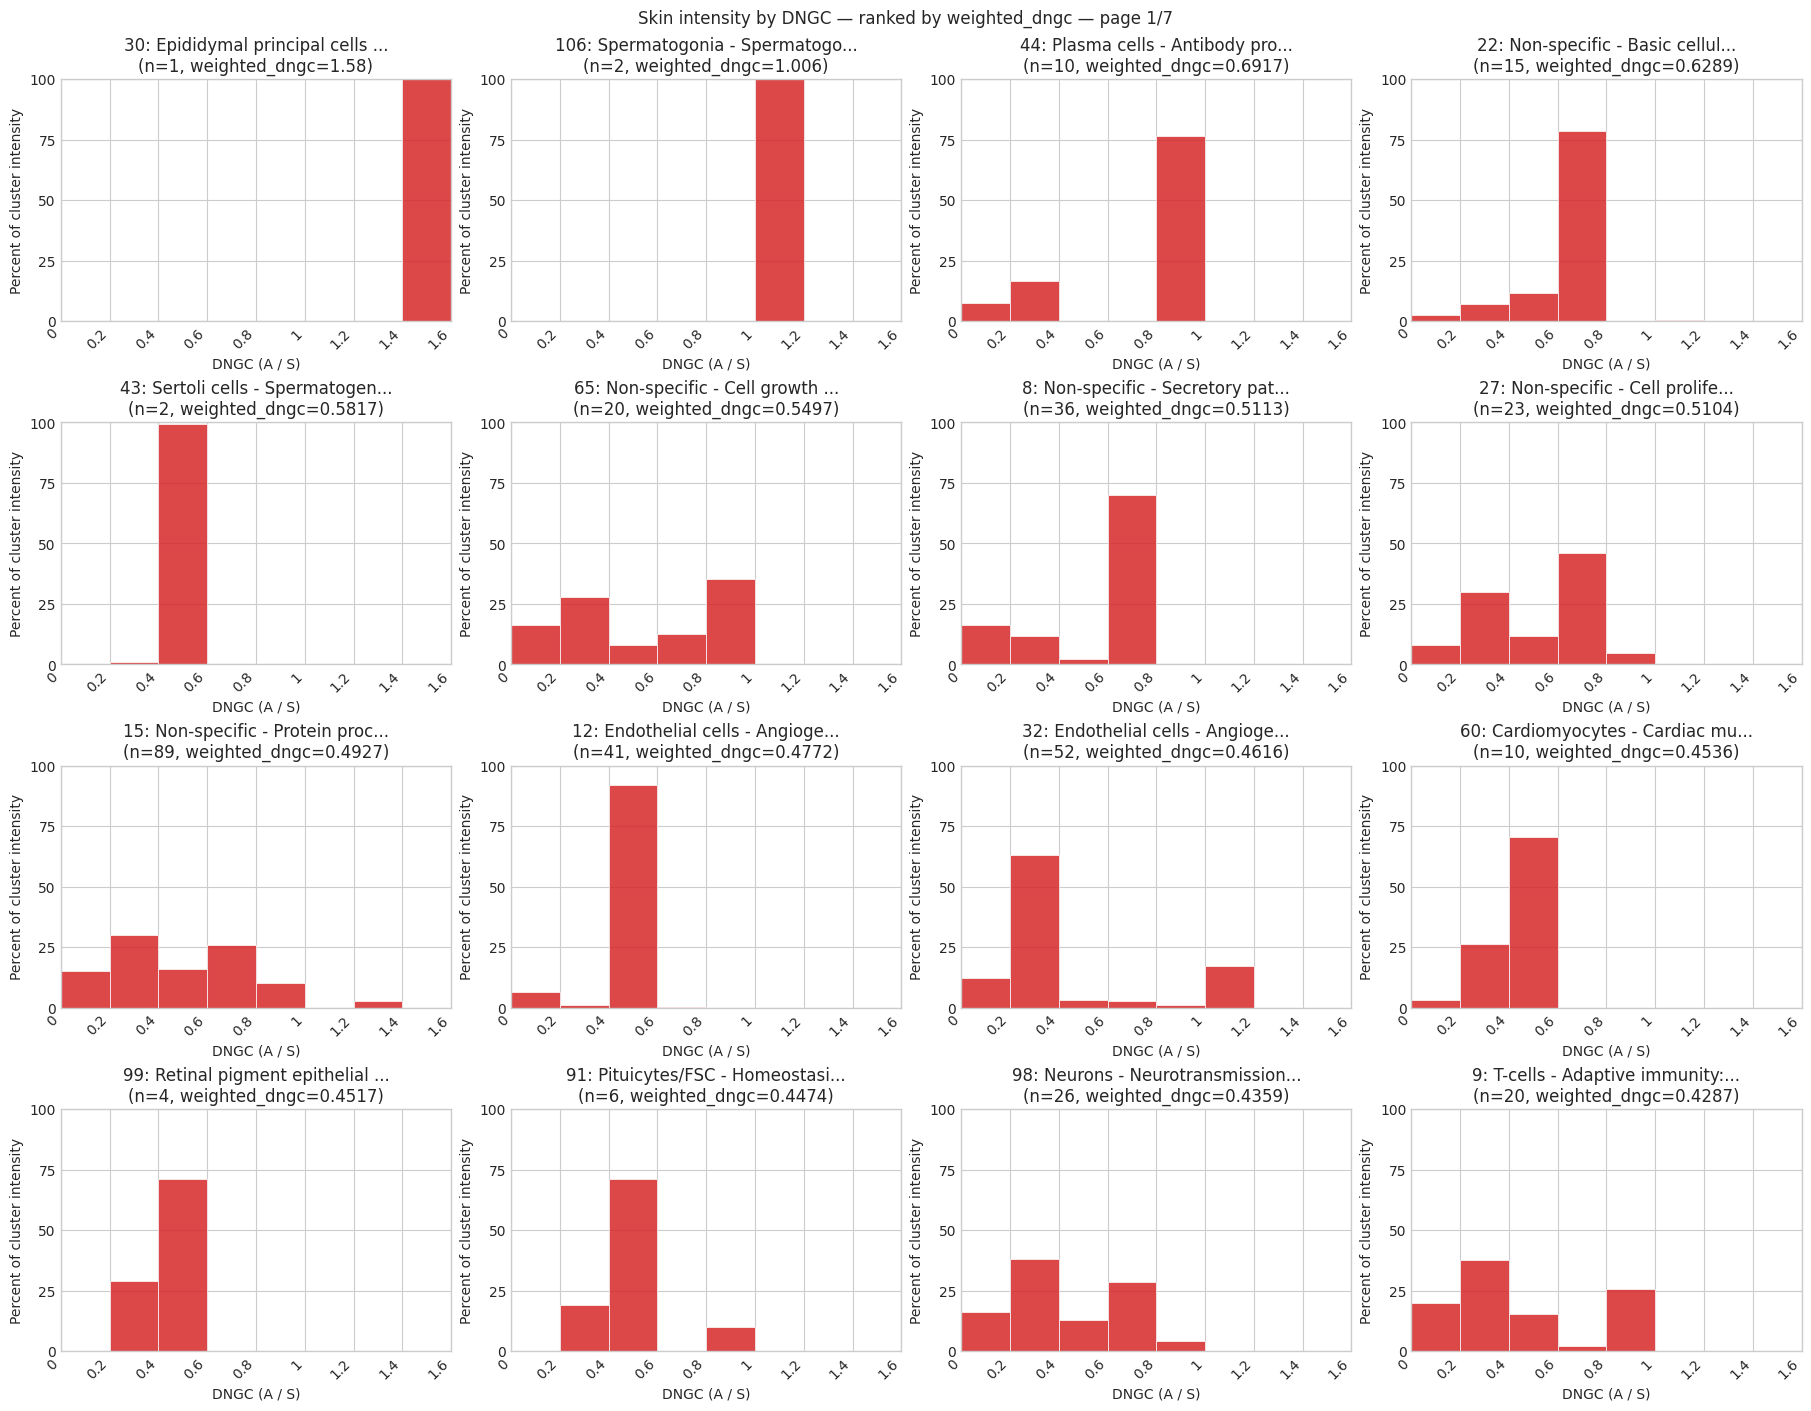

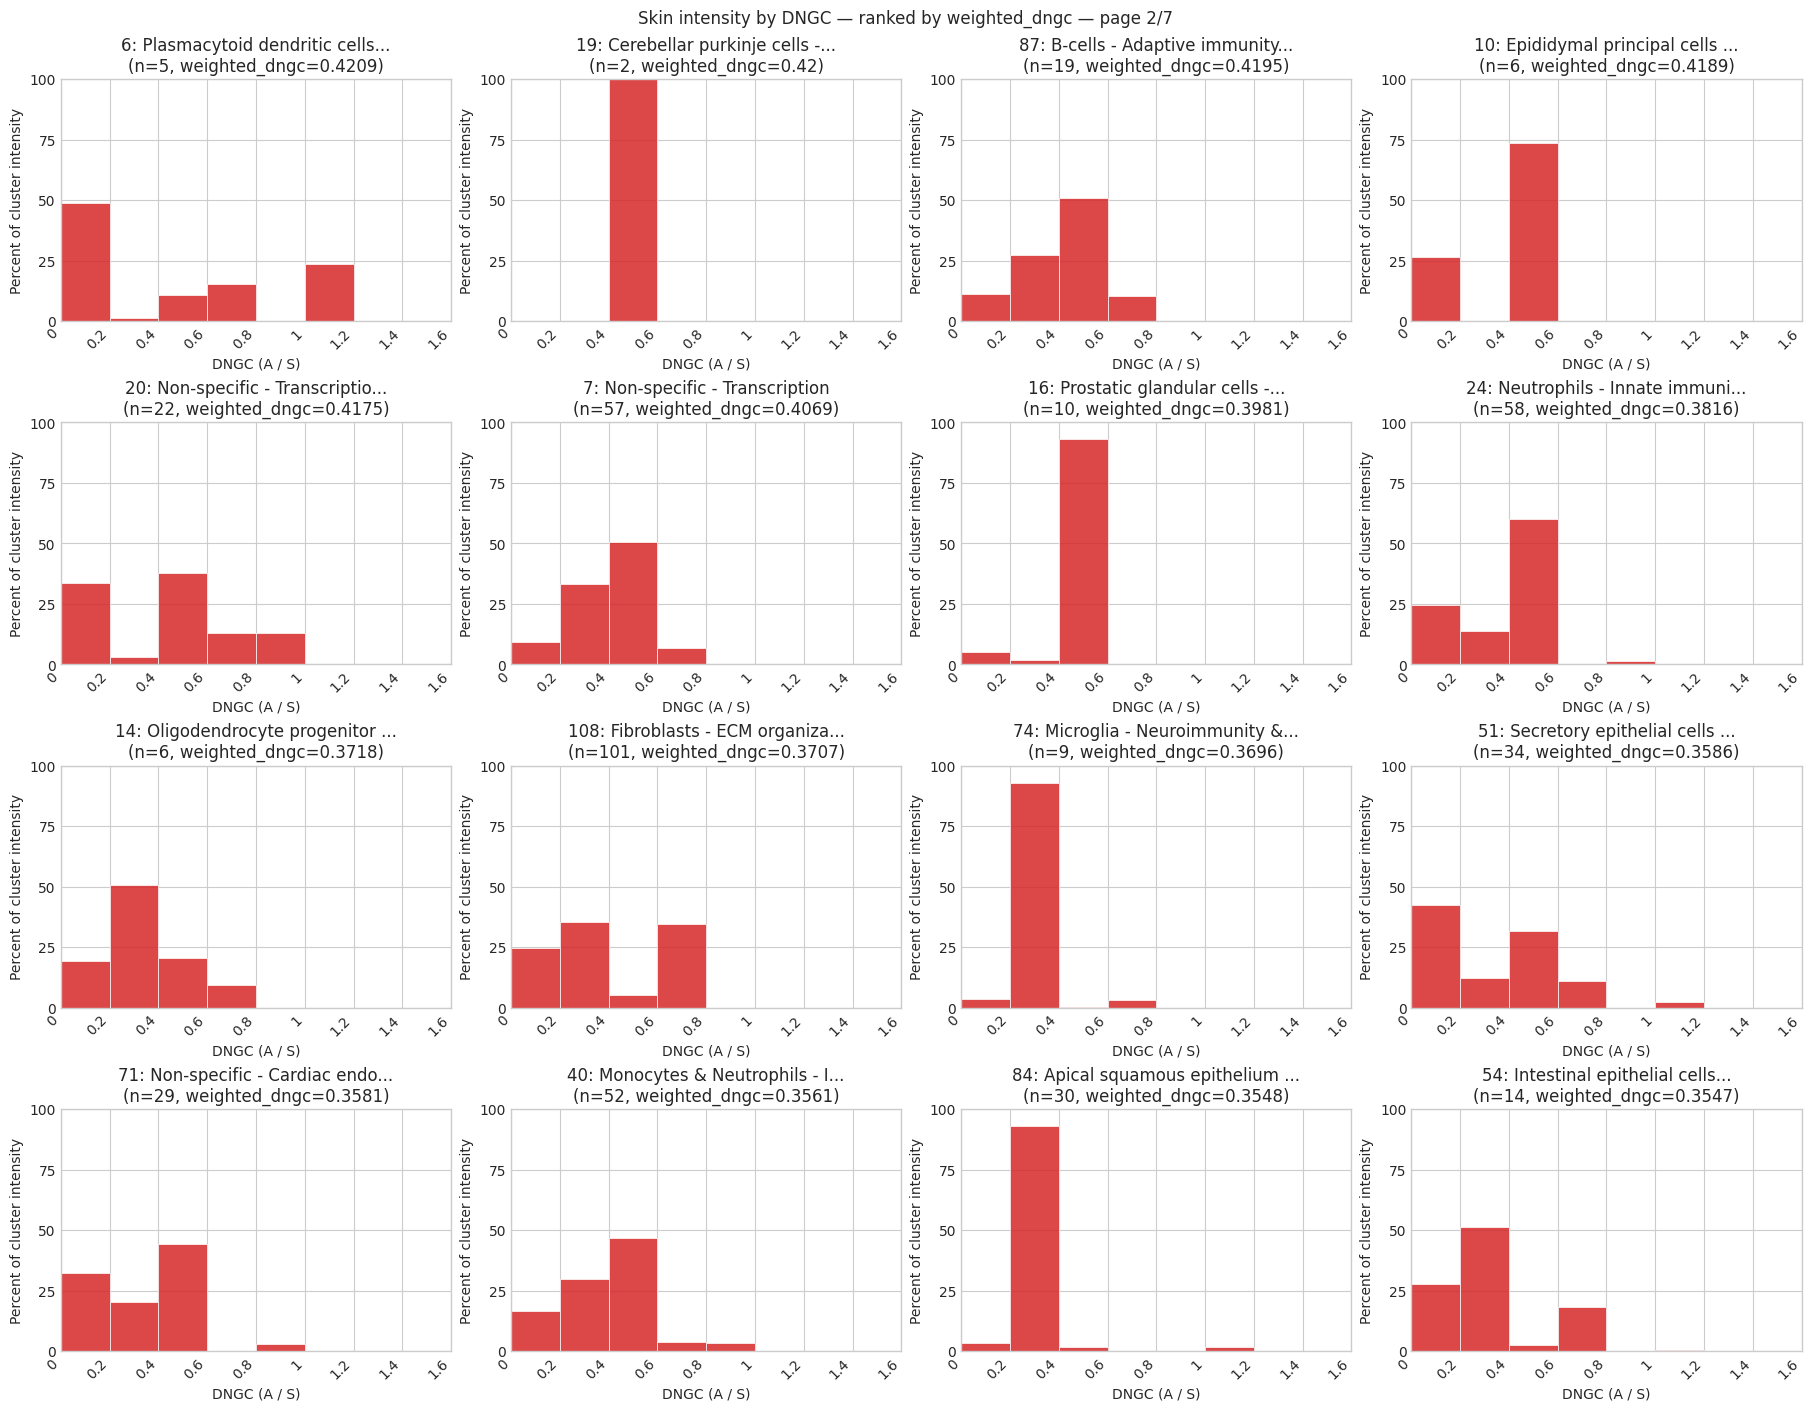

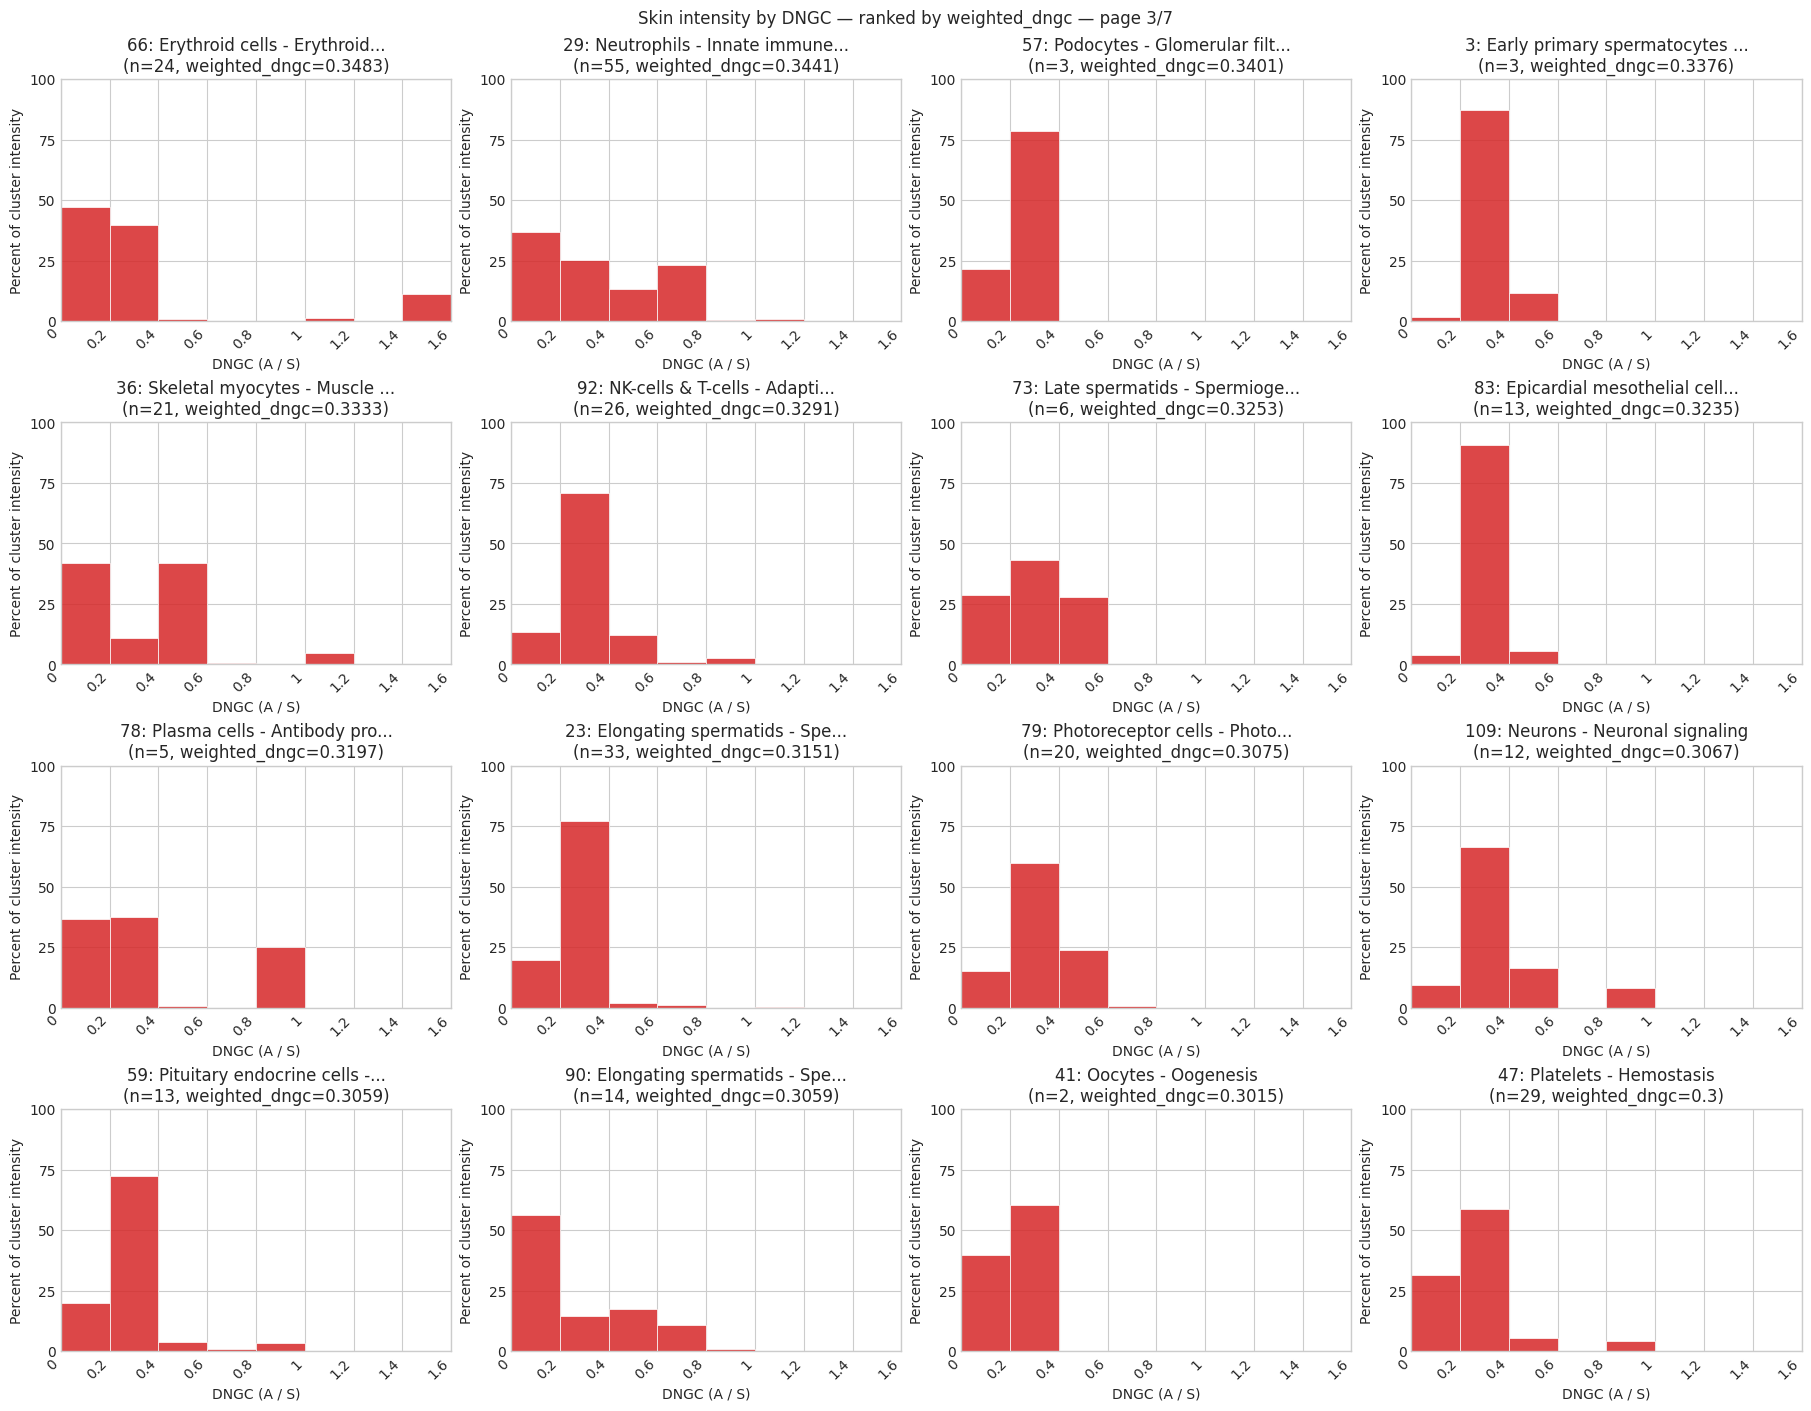

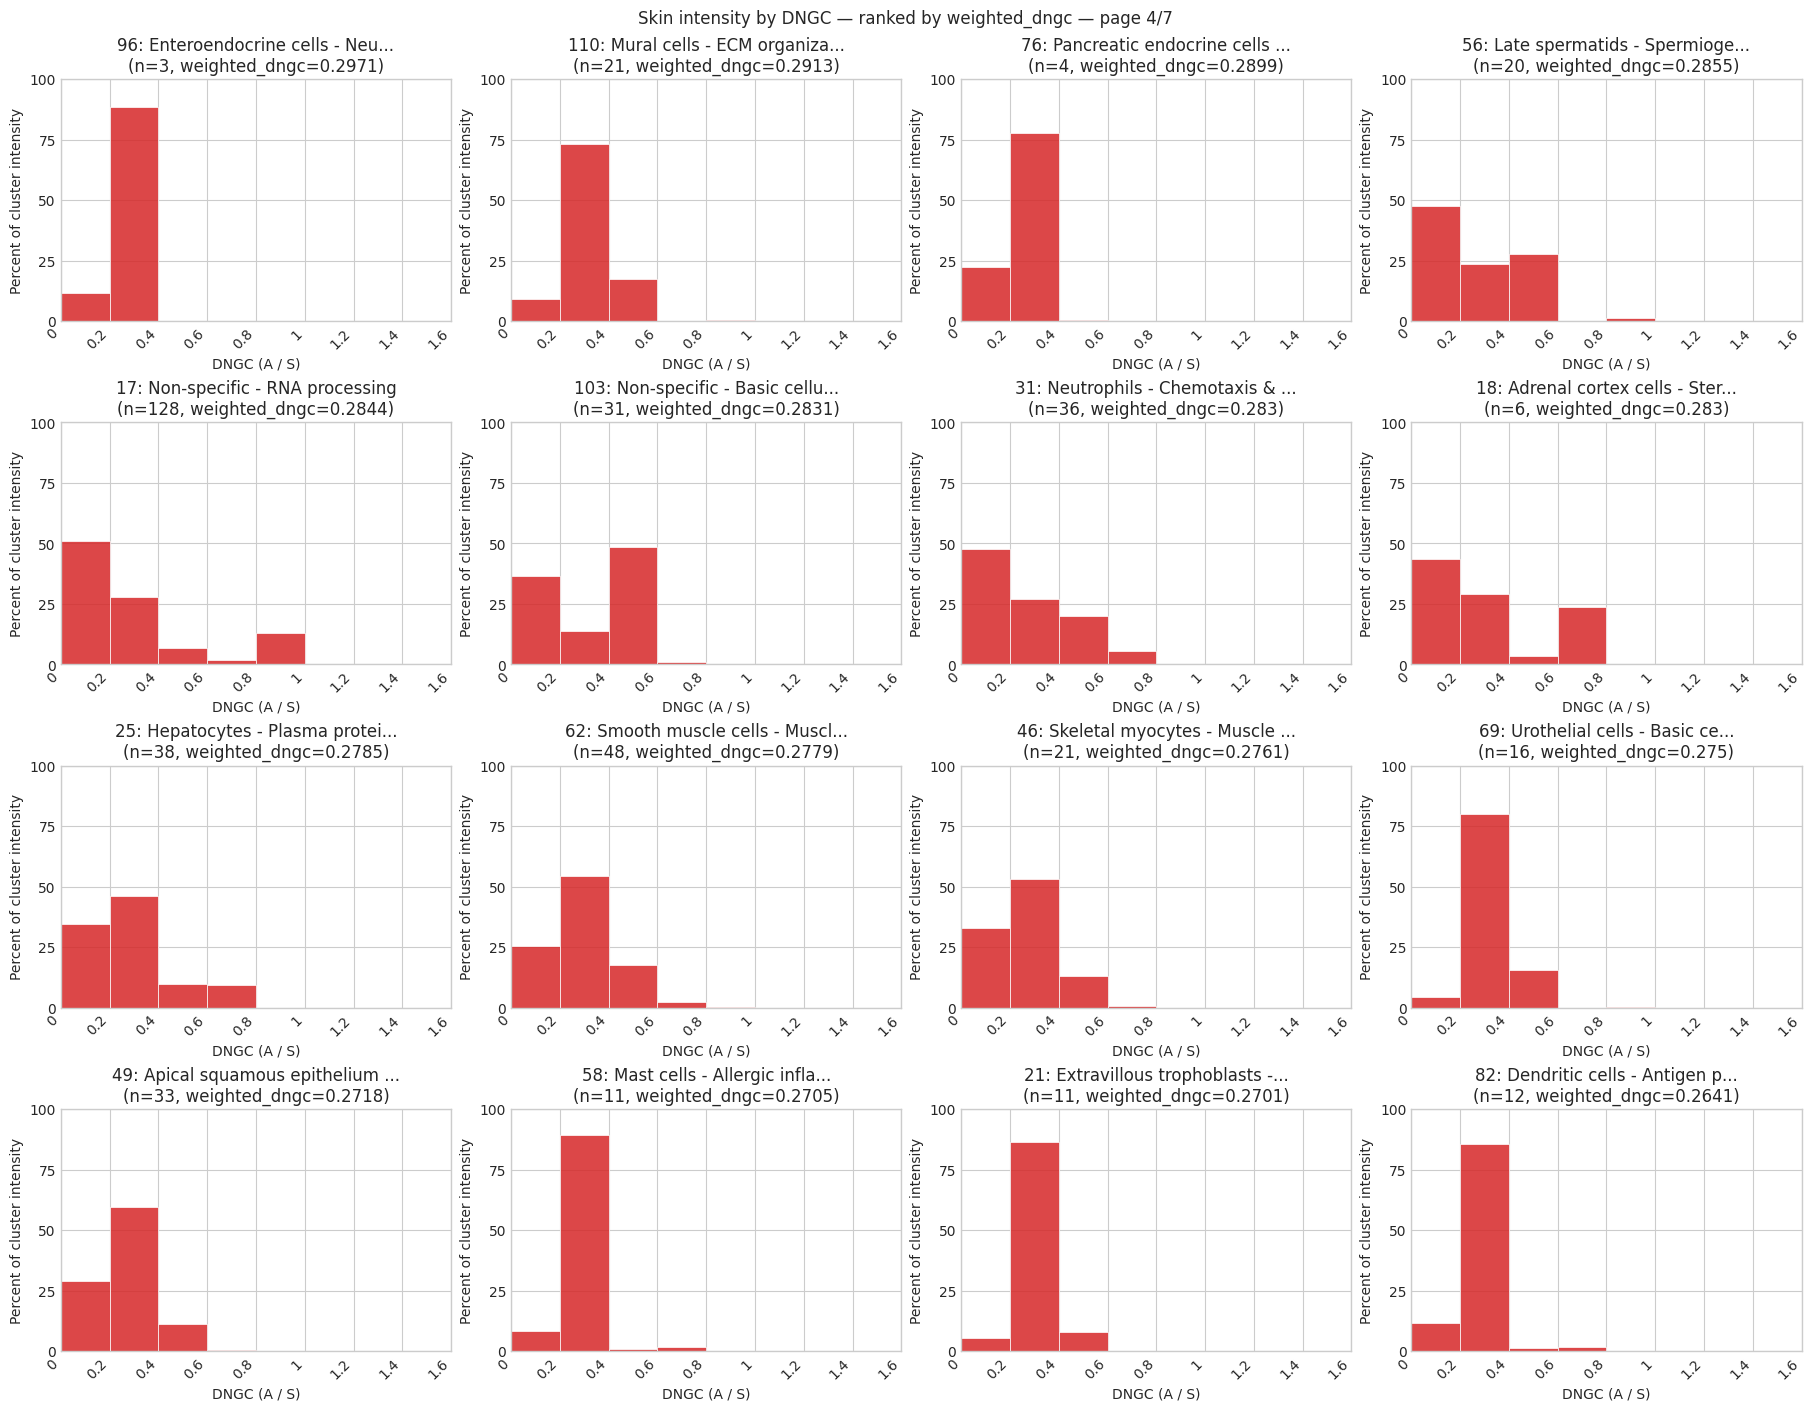

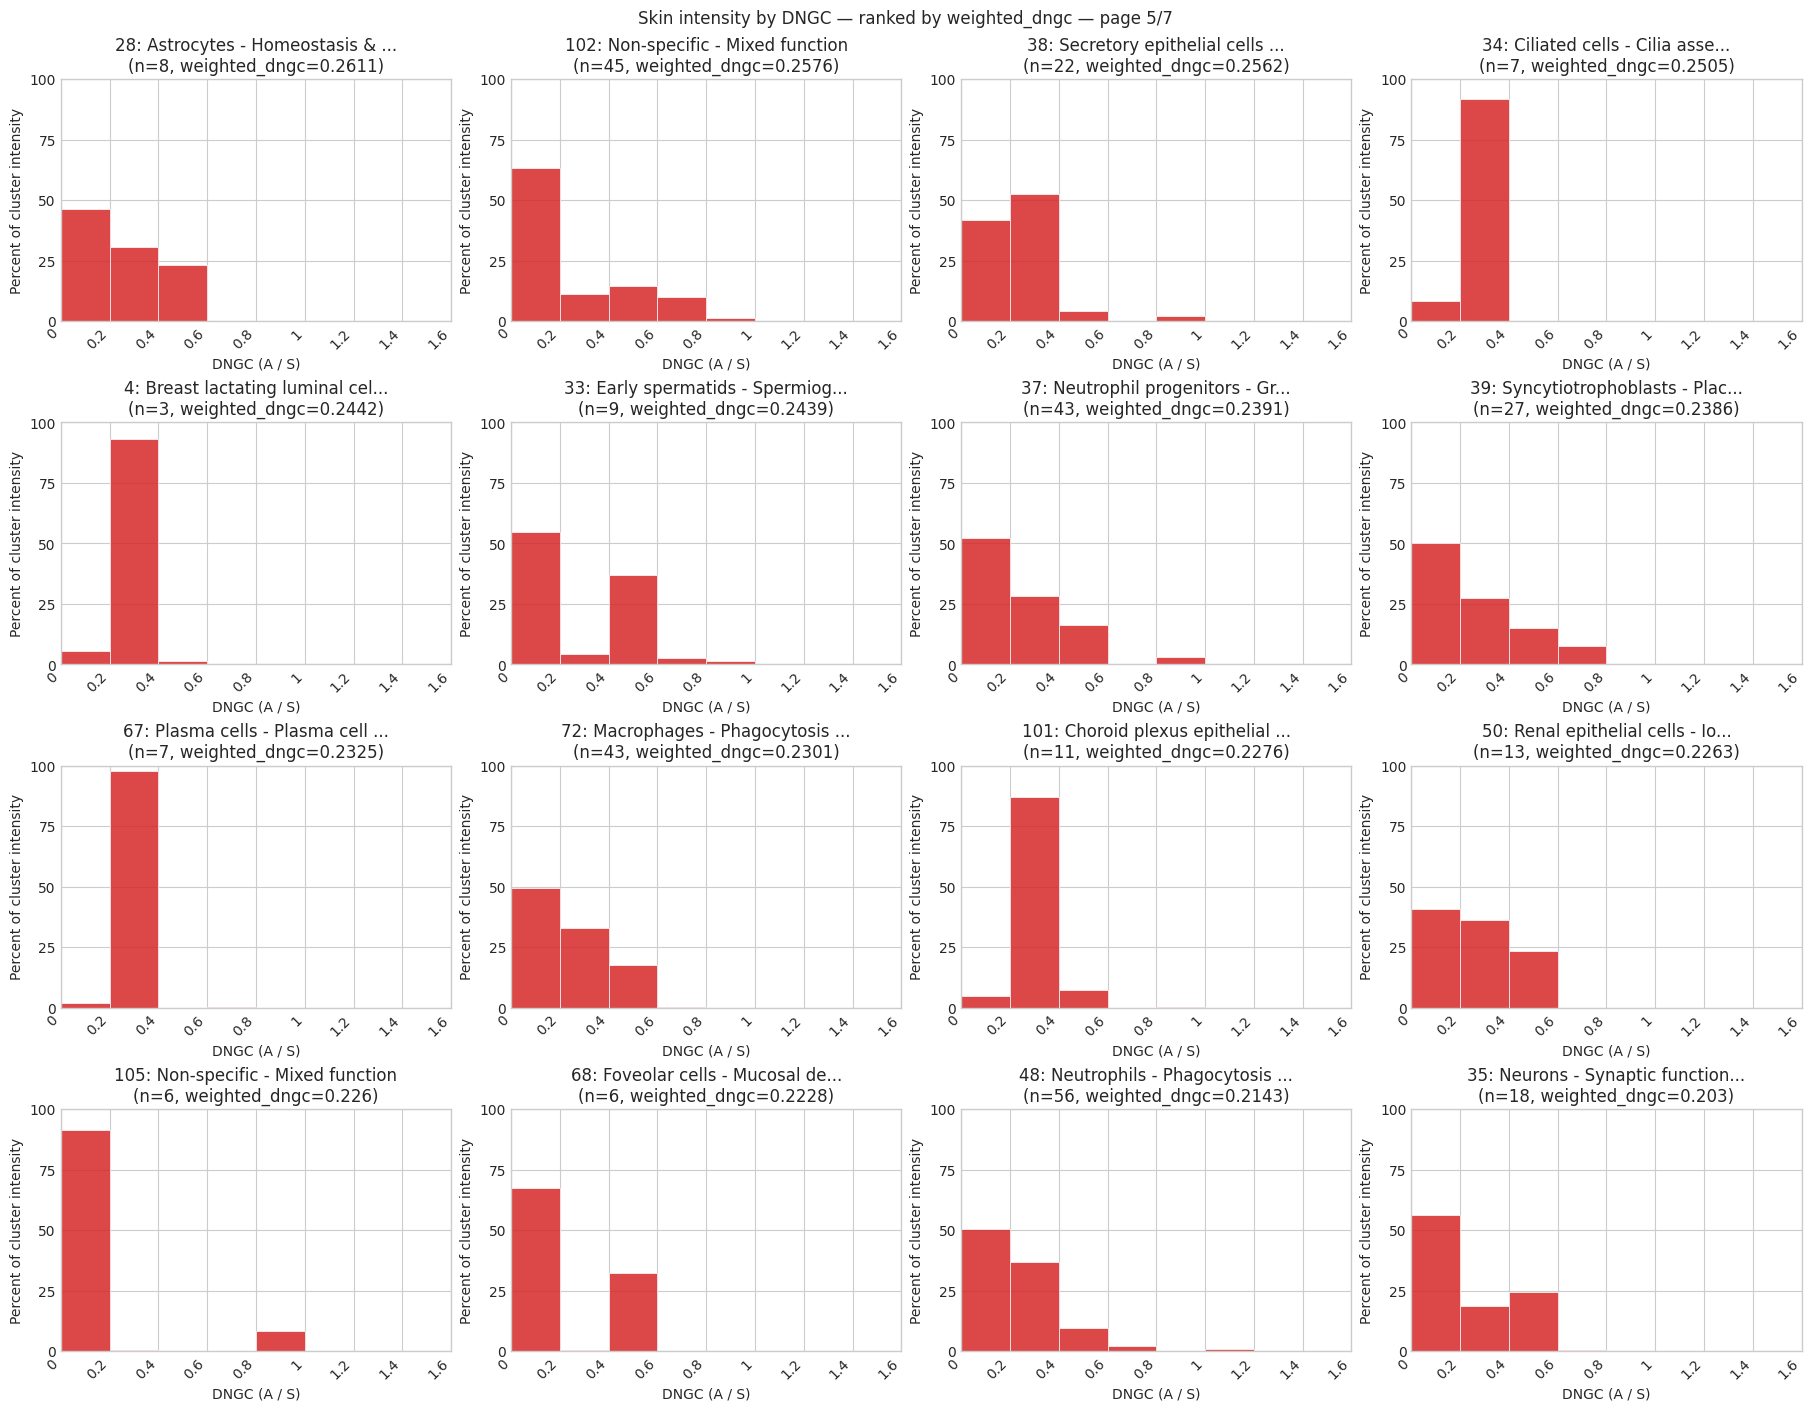

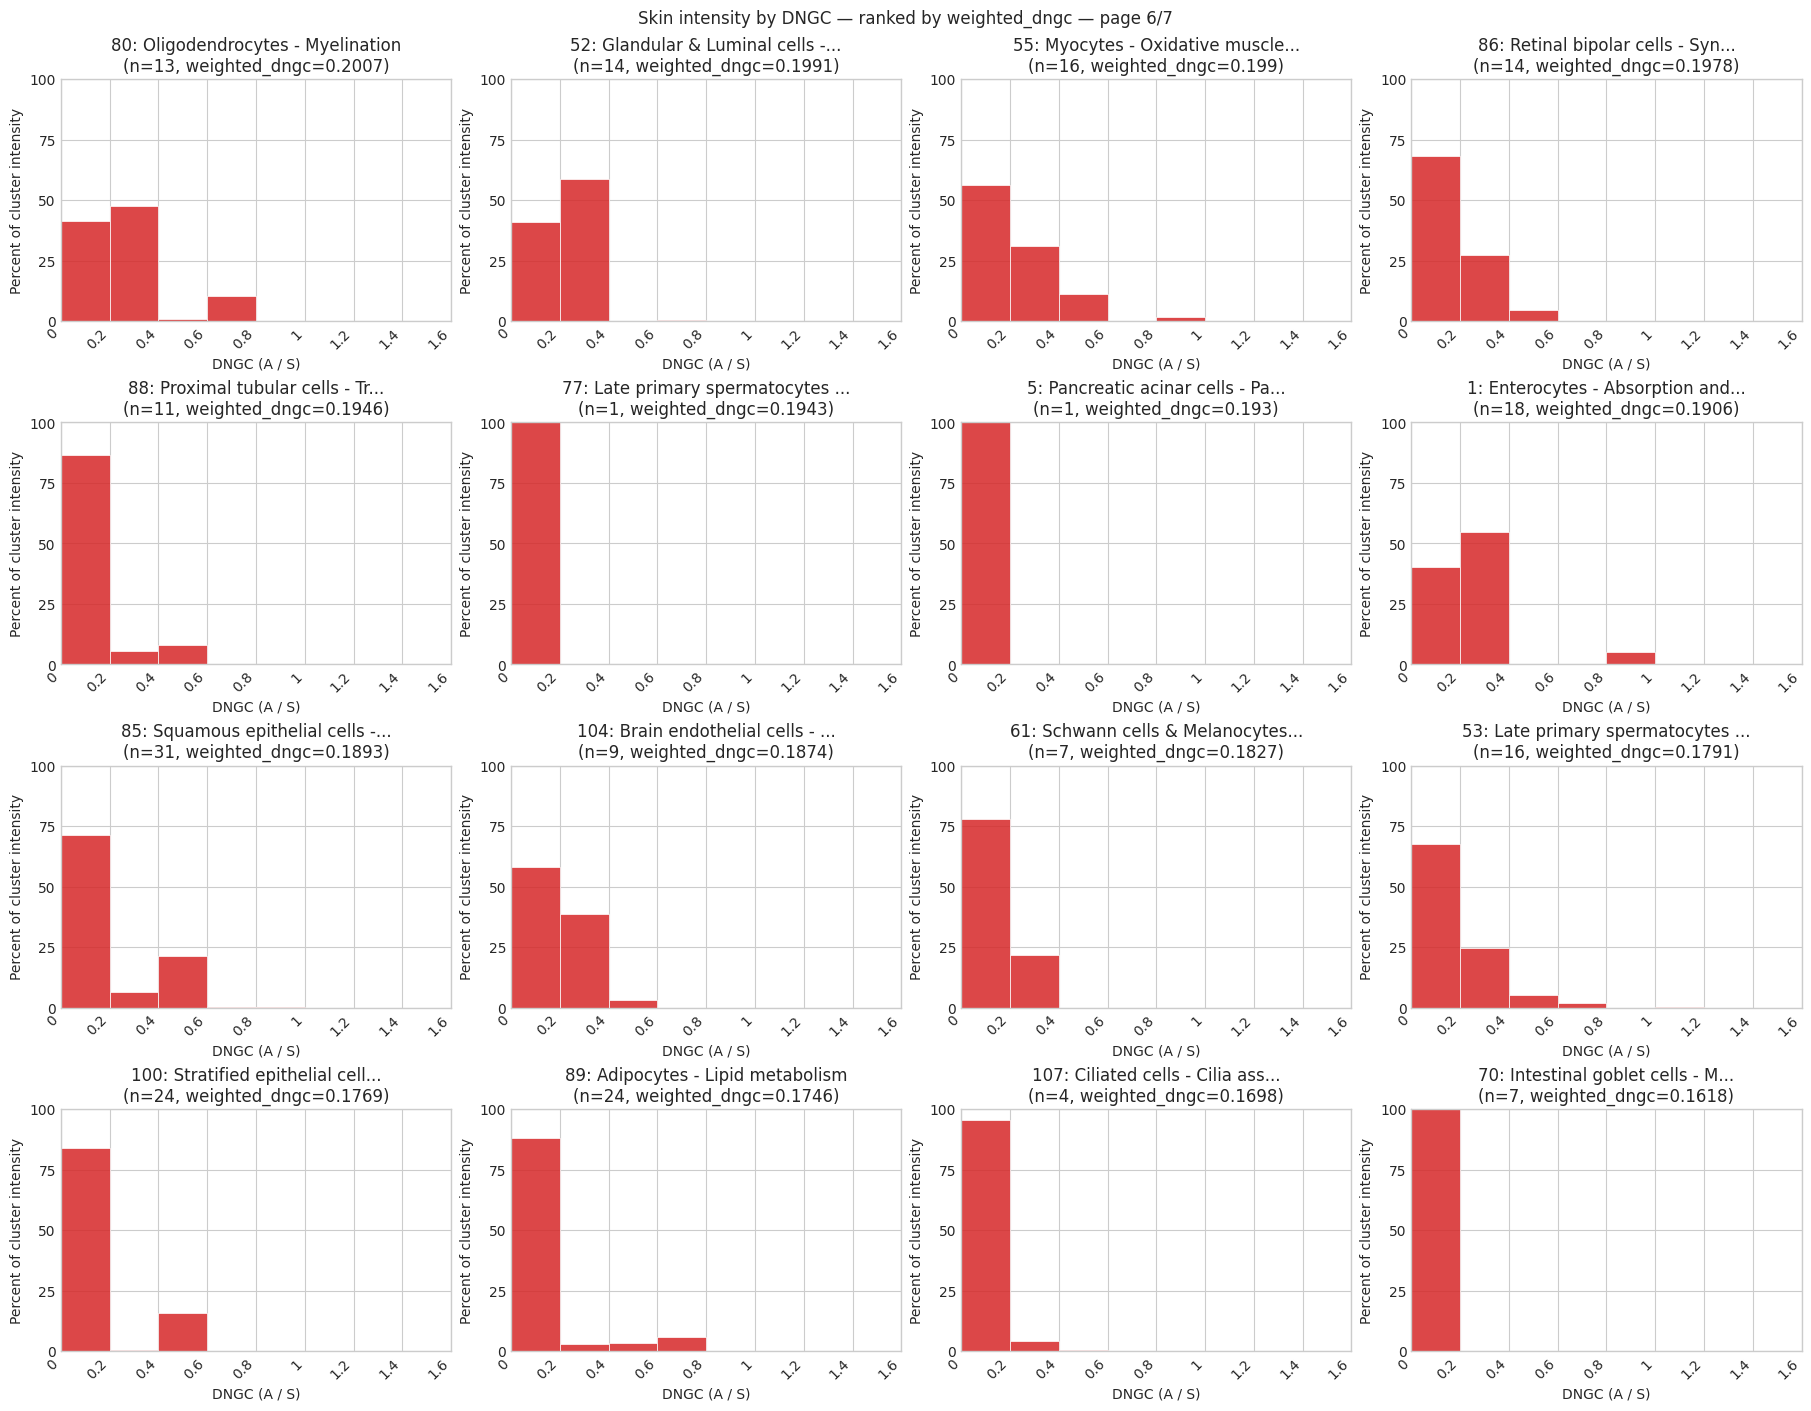

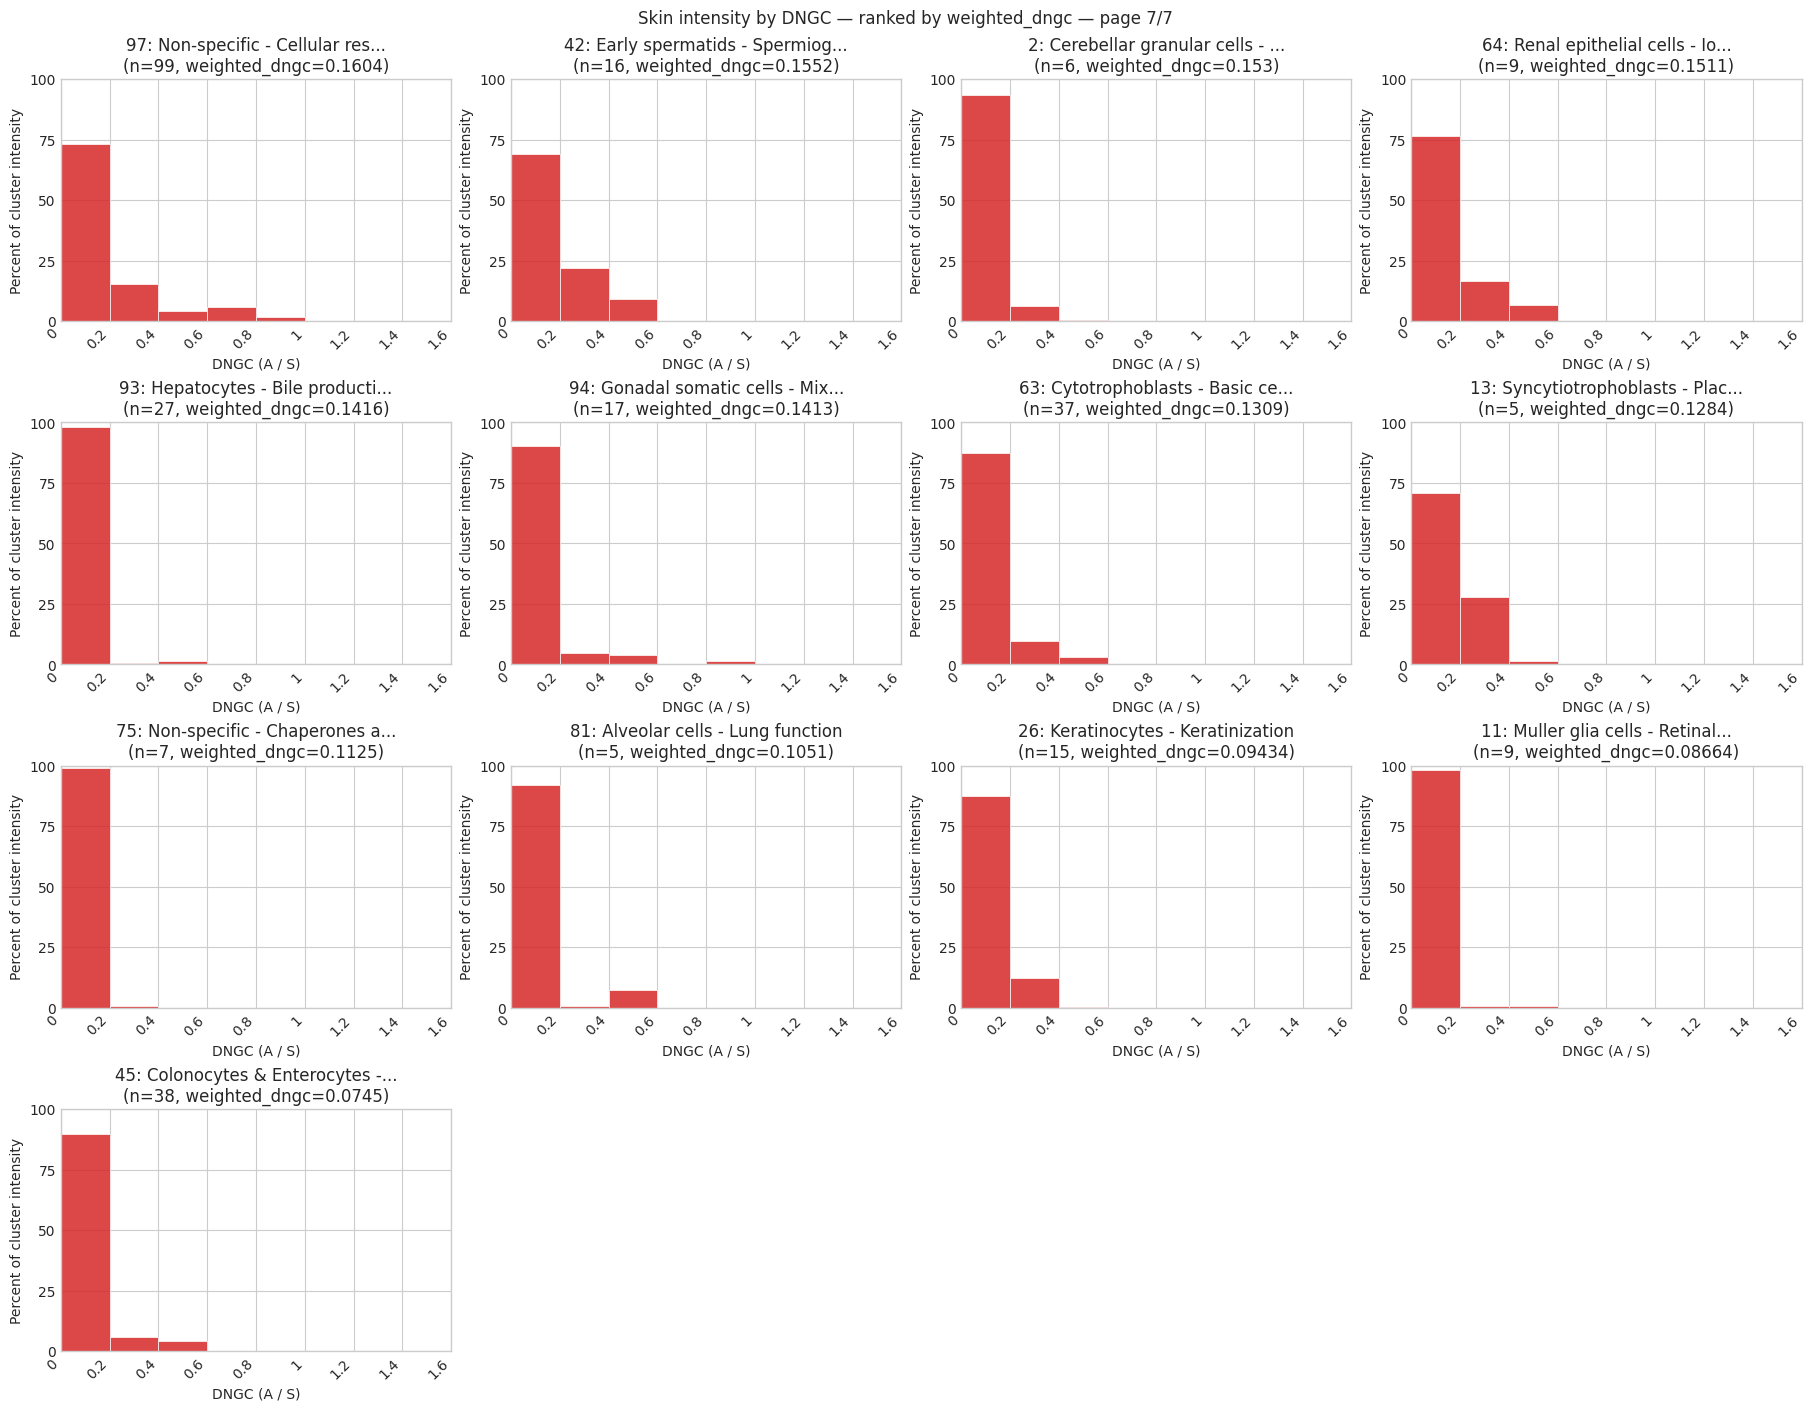

In [ ]:
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")


def short_cluster_label(name: str, max_len: int = 34) -> str:
    text = name[len("Cluster ") :] if name.startswith("Cluster ") else name
    if len(text) <= max_len:
        return text
    return text[: max_len - 3] + "..."


def _nice_bin_width(span: float, target_bins: int = 12) -> float:
    raw = span / max(target_bins, 1)
    if raw <= 0:
        return 1.0
    exponent = np.floor(np.log10(raw))
    fraction = raw / (10 ** exponent)
    if fraction <= 1:
        nice = 1.0
    elif fraction <= 2:
        nice = 2.0
    elif fraction <= 5:
        nice = 5.0
    else:
        nice = 10.0
    return float(nice * (10 ** exponent))


def histogram_bins(values: np.ndarray, target_bins: int = 12) -> np.ndarray:
    finite = values[np.isfinite(values)]
    maximum = float(finite.max()) if finite.size else 0.0
    width = _nice_bin_width(max(maximum, 0.0), target_bins)
    data_upper = max(width, float(np.ceil(maximum / width) * width)) if width else 1.0
    return np.arange(0.0, data_upper + width, width)


def configure_histogram_x_axis(ax, bins: np.ndarray) -> None:
    ax.set_xticks(bins)
    ax.set_xticklabels([f"{edge:g}" for edge in bins])
    if len(bins) > 8:
        ax.tick_params(axis="x", labelrotation=45)
        for label in ax.get_xticklabels():
            label.set_horizontalalignment("right")


@dataclass(frozen=True)
class IntensityStat:
    attribute: str
    folder: str
    xlabel: str
    title: str
    color: str


INTENSITY_STATS = (
    IntensityStat("dngc", "dngc", "DNGC (A / S)", "Skin intensity by DNGC", "C3"),
    IntensityStat("coverage", "coverage", "Coverage (F)", "Skin intensity by coverage", "C0"),
    IntensityStat("potency_auc", "potency", "Potency (A)", "Skin intensity by potency", "C2"),
    IntensityStat("s_score", "s_score", "S score", "Skin intensity by S score", "C1"),
)
DNGC_INTENSITY_STAT = INTENSITY_STATS[0]


def finite_stat_intensity(group: ClusterGroup, attribute: str) -> tuple[np.ndarray, np.ndarray]:
    stat_values = []
    intensity_values = []
    for item in group.profiles:
        if not np.isfinite(item.skin_intensity):
            continue
        stat_values.append(float(getattr(item.statistics, attribute)))
        intensity_values.append(float(item.skin_intensity))
    return (
        np.asarray(stat_values, dtype=np.float64),
        np.asarray(intensity_values, dtype=np.float64),
    )


def shared_stat_bins(groups: list[ClusterGroup], attribute: str) -> np.ndarray:
    pieces = [finite_stat_intensity(group, attribute)[0] for group in groups]
    values = np.concatenate(pieces) if pieces else np.empty(0, dtype=np.float64)
    return histogram_bins(values)


def draw_intensity_histogram(ax, group: ClusterGroup, bins: np.ndarray, stat: IntensityStat) -> None:
    values, intensity = finite_stat_intensity(group, stat.attribute)
    total = float(intensity.sum()) if intensity.size else 0.0
    if values.size and total > 0:
        ax.hist(
            values,
            bins=bins,
            weights=intensity / total * 100.0,
            color=stat.color,
            alpha=0.85,
            edgecolor="white",
            linewidth=0.6,
        )
    else:
        ax.text(0.5, 0.5, "No skin intensity", ha="center", va="center", transform=ax.transAxes, fontsize=8)
    score = group.rank_score
    score_text = "nan" if not np.isfinite(score) else f"{score:.4g}"
    ax.set(
        xlim=(float(bins[0]), float(bins[-1])),
        ylim=(0.0, 100.0),
        xlabel=stat.xlabel,
        ylabel="Percent of cluster intensity",
        title=f"{short_cluster_label(group.name)}\n(n={group.n}, {CLUSTER_ORDER_BY}={score_text})",
    )
    configure_histogram_x_axis(ax, bins)
    ax.set_yticks([0, 25, 50, 75, 100])


def render_histogram_page(
    batch: list[ClusterGroup],
    bins: np.ndarray,
    page: int,
    n_pages: int,
    stat: IntensityStat,
):
    fig, axes = plt.subplots(
        PLOT_GRID_ROWS,
        PLOT_GRID_COLUMNS,
        figsize=(18.0, 14.0),
        layout="constrained",
    )
    flat_axes = np.atleast_1d(axes).ravel()
    for ax, group in zip(flat_axes, batch):
        draw_intensity_histogram(ax, group, bins, stat)
    for ax in flat_axes[len(batch) :]:
        ax.set_visible(False)
    fig.suptitle(f"{stat.title} \u2014 ranked by {CLUSTER_ORDER_BY} \u2014 page {page}/{n_pages}")
    return fig


def prepare_intensity_plot_dir(path: Path) -> Path:
    path.mkdir(parents=True, exist_ok=True)
    for stale in path.glob("page_*.png"):
        stale.unlink()
    return path


def plot_dngc_intensity_histograms(groups: list[ClusterGroup]) -> None:
    if not groups:
        print("No clusters to plot.")
        return
    stat = DNGC_INTENSITY_STAT
    bins = shared_stat_bins(groups, stat.attribute)
    pages = cluster_pages(groups, PLOT_GRID_ROWS * PLOT_GRID_COLUMNS)
    n_pages = len(pages)
    print(
        f"Plotting {len(groups)} clusters ranked by {CLUSTER_ORDER_BY} "
        f"on {n_pages} {PLOT_GRID_ROWS}x{PLOT_GRID_COLUMNS} page(s)."
    )
    for page, batch in enumerate(pages, start=1):
        render_histogram_page(batch, bins, page, n_pages, stat)
        plt.show()


plot_dngc_intensity_histograms(clusters)


## Fragment length vs DNGC heatmaps

The first ranking page is one grid of fragment-length versus DNGC heatmaps, using the same aggregation as the single-cluster heatmap. Each panel is one of the 16 clusters on that page.

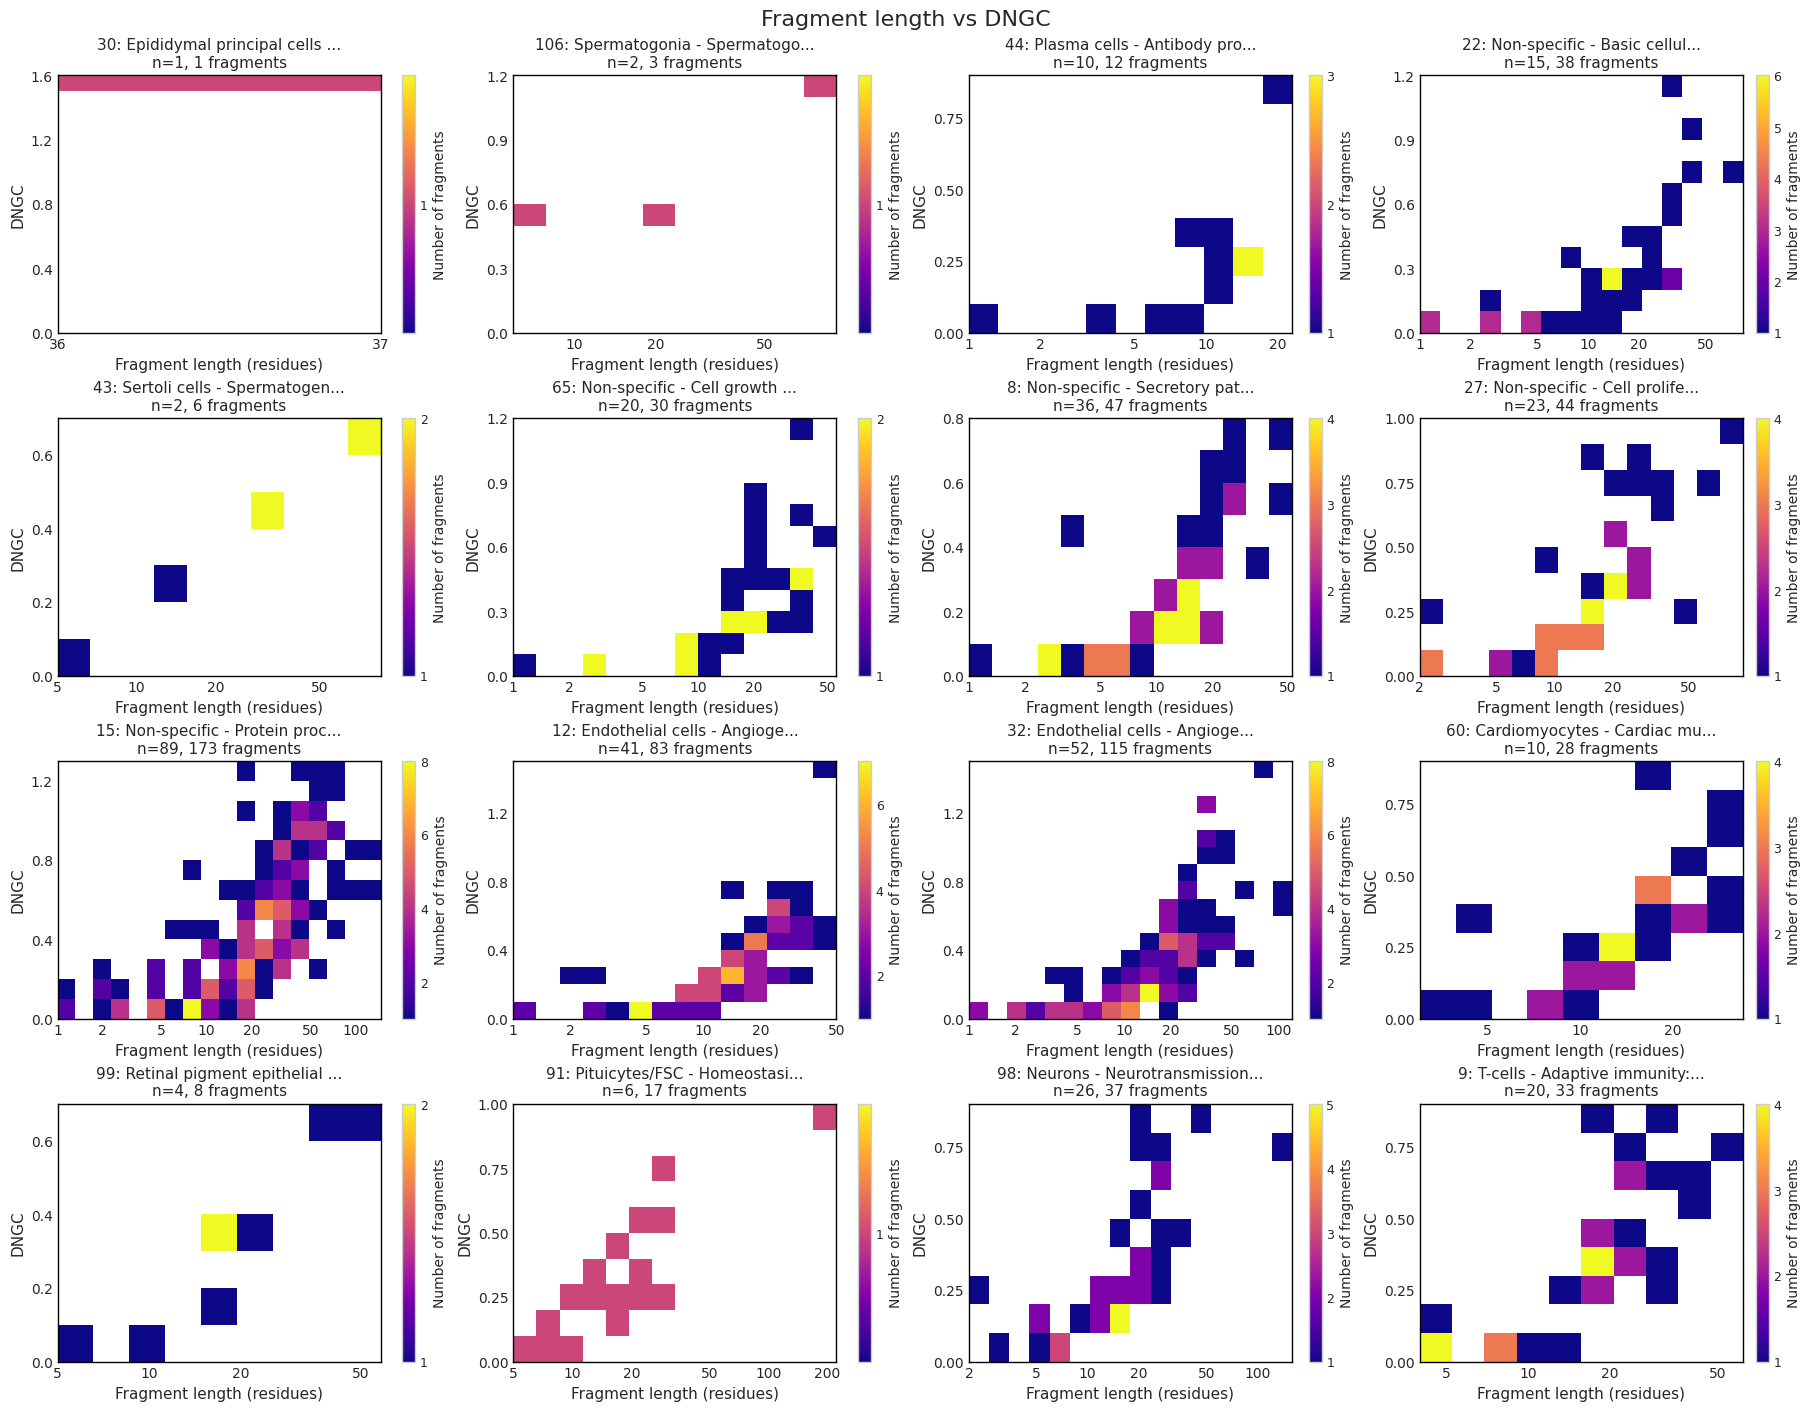

In [ ]:
from matplotlib.ticker import FuncFormatter, LogLocator, MaxNLocator


def active_fragment_spans(sigma: np.ndarray) -> list[tuple[int, int, float]]:
    active = activity_mask(sigma)
    if active.size == 0 or not np.any(active):
        return []
    padded = np.concatenate([[False], active, [False]])
    changes = np.diff(padded.astype(np.int8))
    starts = np.flatnonzero(changes == 1)
    ends = np.flatnonzero(changes == -1)
    spans = []
    for start, end in zip(starts, ends):
        segment = sigma[start:end]
        spans.append((int(start), int(end), float(np.sum(segment) / segment.size)))
    return spans


def fragment_length_dngc(group: ClusterGroup) -> tuple[np.ndarray, np.ndarray]:
    lengths: list[float] = []
    scores: list[float] = []
    for item in group.profiles:
        for start, end, dngc in active_fragment_spans(item.sigma):
            length = end - start
            if length <= 0 or not np.isfinite(dngc):
                continue
            lengths.append(float(length))
            scores.append(dngc)
    return np.asarray(lengths, dtype=np.float64), np.asarray(scores, dtype=np.float64)


def _integer_span_ticks(low: int, high: int) -> list[int]:
    if high < low:
        low, high = high, low
    if high == low:
        return [low]
    raw = MaxNLocator(integer=True, nbins=5, min_n_ticks=2).tick_values(low, high)
    ticks = sorted({int(round(value)) for value in raw if low <= value <= high})
    return ticks or [low, high]


def _log_length_edges(low: float, high: float, bins_per_decade: int = 8) -> np.ndarray:
    low = max(1.0, low)
    high = max(high, low + 1.0)
    n_bins = max(1, int(np.ceil(np.log10(high / low) * bins_per_decade)))
    edges = np.geomspace(low, high, n_bins + 1)
    edges[0] = low
    edges[-1] = high
    return edges


def _integer_tick_label(value: float, _position: object) -> str:
    rounded = int(round(value))
    if rounded < 1 or abs(value - rounded) > 1e-4 * value:
        return ""
    return str(rounded)


def _fragment_heatmap_edges(lengths: np.ndarray, scores: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    x_lo = max(1.0, float(np.floor(lengths.min())))
    x_hi = float(np.ceil(lengths.max()))
    if x_hi <= x_lo:
        x_hi = x_lo + 1.0
    y_hi = float(scores.max())
    y_step = 0.1 if y_hi <= 2.5 else 0.25
    y_hi = float(np.ceil((y_hi + 1e-9) / y_step) * y_step)
    return _log_length_edges(x_lo, x_hi), np.arange(0.0, y_hi + y_step * 0.5, y_step)


def _style_fragment_heatmap_axis(ax) -> None:
    ax.set_facecolor("white")
    ax.grid(False)
    for spine in ax.spines.values():
        spine.set_visible(True)
        spine.set_color("black")


def _heatmap_panel_title(group: ClusterGroup, fragment_count: int) -> str:
    return f"{short_cluster_label(group.name)}\nn={group.n}, {fragment_count} fragments"


def draw_fragment_length_dngc_heatmap(ax, group: ClusterGroup) -> None:
    lengths, scores = fragment_length_dngc(group)
    title = _heatmap_panel_title(group, int(lengths.size))
    _style_fragment_heatmap_axis(ax)
    if lengths.size == 0:
        ax.text(0.5, 0.5, "No fragments", ha="center", va="center", transform=ax.transAxes, fontsize=11)
        ax.set_xlabel("Fragment length (residues)", fontsize=11)
        ax.set_ylabel("DNGC", fontsize=11)
        ax.set_title(title, fontsize=11)
        ax.tick_params(labelsize=10)
        return

    x_edges, y_edges = _fragment_heatmap_edges(lengths, scores)
    counts, _, _ = np.histogram2d(lengths, scores, bins=[x_edges, y_edges])
    masked = np.ma.masked_where(counts.T == 0, counts.T)
    peak = int(counts.max()) if counts.size else 1
    mesh = ax.pcolormesh(
        x_edges,
        y_edges,
        masked,
        cmap="plasma",
        vmin=1,
        vmax=max(peak, 1),
        shading="flat",
    )
    colorbar = ax.figure.colorbar(mesh, ax=ax, fraction=0.046, pad=0.04)
    colorbar.set_label("Number of fragments", fontsize=10)
    colorbar.ax.tick_params(labelsize=9)
    count_ticks = _integer_span_ticks(1, max(peak, 1))
    colorbar.set_ticks(count_ticks)
    colorbar.set_ticklabels([str(tick) for tick in count_ticks])

    ax.set_xscale("log")
    ax.set_xlim(x_edges[0], x_edges[-1])
    ax.set_ylim(y_edges[0], y_edges[-1])
    ax.margins(x=0, y=0)
    ax.xaxis.set_major_locator(LogLocator(base=10, subs=(1, 2, 5)))
    ax.xaxis.set_major_formatter(FuncFormatter(_integer_tick_label))
    ax.xaxis.minorticks_off()
    ax.yaxis.set_major_locator(MaxNLocator(nbins=4, min_n_ticks=2))
    ax.tick_params(labelsize=10)
    ax.set_xlabel("Fragment length (residues)", fontsize=11)
    ax.set_ylabel("DNGC", fontsize=11)
    ax.set_title(title, fontsize=11)


def plot_first_page_heatmaps(groups: list[ClusterGroup]) -> None:
    page_size = PLOT_GRID_ROWS * PLOT_GRID_COLUMNS
    pages = cluster_pages(groups, page_size)
    if not pages:
        print("No clusters to plot.")
        return
    batch = pages[0]
    fig, axes = plt.subplots(
        PLOT_GRID_ROWS,
        PLOT_GRID_COLUMNS,
        figsize=(18.0, 14.0),
        layout="constrained",
    )
    flat_axes = np.atleast_1d(axes).ravel()
    for ax, group in zip(flat_axes, batch):
        draw_fragment_length_dngc_heatmap(ax, group)
    for ax in flat_axes[len(batch) :]:
        ax.set_visible(False)
    fig.suptitle("Fragment length vs DNGC", fontsize=16)
    plt.show()


plot_first_page_heatmaps(clusters)


## Skin intensity distributions

Histograms for the same top 16 clusters. The x-axis is skin intensity in millions, and the y-axis is the number of proteins in each bin. The title shows how many proteins remain after the DNGC cut and how many of those have no skin intensity.

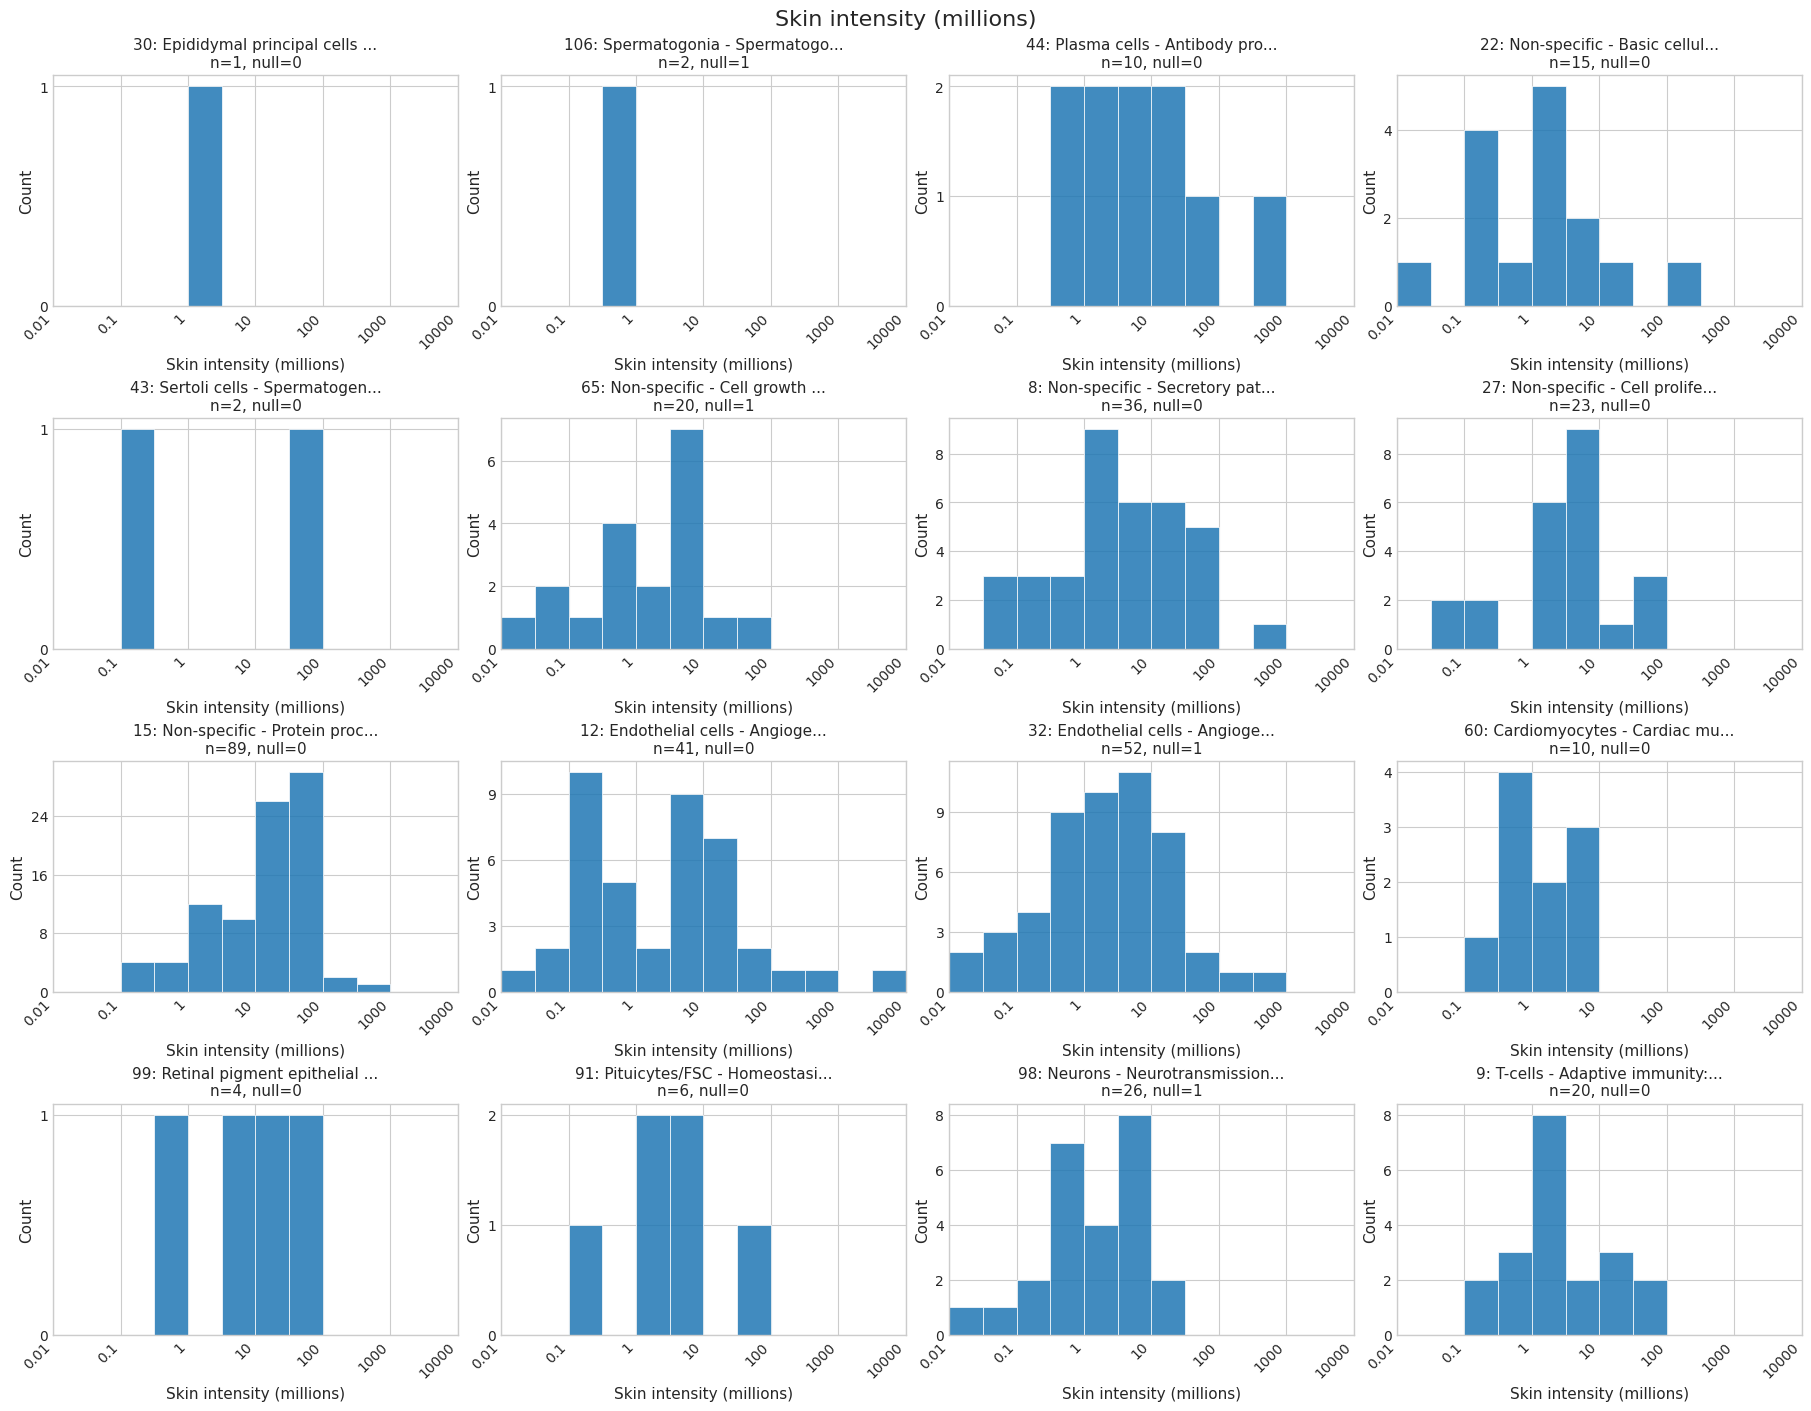

In [134]:
INTENSITY_MILLION = 1_000_000


def _million_axis_label(value: float, _position: object) -> str:
    if value <= 0:
        return ""
    log_value = np.log10(value)
    if abs(log_value - round(log_value)) > 0.01:
        return ""
    number = 10 ** int(round(log_value))
    if number >= 1:
        return f"{number:.0f}"
    return f"{number:g}"


def positive_skin_intensity(group: ClusterGroup) -> np.ndarray:
    values = [
        item.skin_intensity
        for item in group.profiles
        if np.isfinite(item.skin_intensity) and item.skin_intensity > 0
    ]
    return np.asarray(values, dtype=np.float64)


def intensity_millions(group: ClusterGroup) -> np.ndarray:
    return positive_skin_intensity(group) / INTENSITY_MILLION


def null_skin_intensity_count(group: ClusterGroup) -> int:
    return sum(not np.isfinite(item.skin_intensity) for item in group.profiles)


def log_intensity_bins(groups: list[ClusterGroup], bins_per_decade: int = 2) -> np.ndarray:
    pieces = [intensity_millions(group) for group in groups]
    values = np.concatenate([piece for piece in pieces if piece.size]) if pieces else np.empty(0)
    if values.size == 0:
        return np.array([0.01, 0.1])
    low = 10 ** np.floor(np.log10(float(values.min())))
    high = 10 ** np.ceil(np.log10(float(values.max())))
    if high <= low:
        high = low * 10
    n_bins = max(1, int(round(np.log10(high / low) * bins_per_decade)))
    return np.logspace(np.log10(low), np.log10(high), n_bins + 1)


def draw_skin_intensity_histogram(ax, group: ClusterGroup, bins: np.ndarray) -> None:
    values = intensity_millions(group)
    if values.size:
        ax.hist(
            values,
            bins=bins,
            color="C0",
            alpha=0.85,
            edgecolor="white",
            linewidth=0.6,
        )
    else:
        ax.text(0.5, 0.5, "No skin intensity", ha="center", va="center", transform=ax.transAxes, fontsize=11)
    ax.set_xscale("log")
    ax.set_xlim(float(bins[0]), float(bins[-1]))
    ax.set_xlabel("Skin intensity (millions)", fontsize=11)
    ax.set_ylabel("Count", fontsize=11)
    ax.set_title(
        f"{short_cluster_label(group.name)}\n"
        f"n={group.n}, null={null_skin_intensity_count(group)}",
        fontsize=11,
    )
    ax.xaxis.set_major_locator(LogLocator(base=10))
    ax.xaxis.set_major_formatter(FuncFormatter(_million_axis_label))
    ax.xaxis.minorticks_off()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True, nbins=5, min_n_ticks=2))
    ax.tick_params(labelsize=10)
    ax.tick_params(axis="x", labelrotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")


def plot_top_intensity_histograms(groups: list[ClusterGroup]) -> None:
    page_size = PLOT_GRID_ROWS * PLOT_GRID_COLUMNS
    batch = groups[:page_size]
    if not batch:
        print("No clusters to plot.")
        return
    bins = log_intensity_bins(batch)
    fig, axes = plt.subplots(
        PLOT_GRID_ROWS,
        PLOT_GRID_COLUMNS,
        figsize=(18.0, 14.0),
        layout="constrained",
    )
    flat_axes = np.atleast_1d(axes).ravel()
    for ax, group in zip(flat_axes, batch):
        draw_skin_intensity_histogram(ax, group, bins)
    for ax in flat_axes[len(batch) :]:
        ax.set_visible(False)
    fig.suptitle("Skin intensity (millions)", fontsize=16)
    plt.show()


plot_top_intensity_histograms(clusters[: PLOT_GRID_ROWS * PLOT_GRID_COLUMNS])


## Save statistic histograms

When `SAVE_CLUSTER_PLOTS` is enabled, intensity-weighted histogram pages for DNGC, coverage, potency, and S score are written under `INTENSITY_PLOT_DIR`, one folder per statistic.

In [135]:
def clear_flat_intensity_pages(path: Path) -> None:
    if not path.is_dir():
        return
    for stale in path.glob("page_*.png"):
        stale.unlink()


def save_intensity_stat_plots(groups: list[ClusterGroup]) -> None:
    if not SAVE_CLUSTER_PLOTS:
        print("Cluster plot saving is off.")
        return
    if not groups:
        print("No clusters to plot.")
        return
    clear_flat_intensity_pages(INTENSITY_PLOT_DIR)
    page_size = PLOT_GRID_ROWS * PLOT_GRID_COLUMNS
    for stat in INTENSITY_STATS:
        save_dir = prepare_intensity_plot_dir(INTENSITY_PLOT_DIR / stat.folder)
        bins = shared_stat_bins(groups, stat.attribute)
        pages = cluster_pages(groups, page_size)
        print(f"Saving {len(pages)} {stat.folder} page(s) to {save_dir}")
        for page, batch in enumerate(pages, start=1):
            fig = render_histogram_page(batch, bins, page, len(pages), stat)
            fig.savefig(save_dir / f"page_{page:02d}.png", dpi=SAVE_DPI, bbox_inches="tight")
            plt.close(fig)


save_intensity_stat_plots(clusters)


Saving 7 dngc page(s) to /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/skin_intensity_cluster_plots/dngc
Saving 7 coverage page(s) to /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/skin_intensity_cluster_plots/coverage
Saving 7 potency page(s) to /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/skin_intensity_cluster_plots/potency
Saving 7 s_score page(s) to /mnt/c/Users/bioin/Documents/Peptide-Anti-microbial-Properties-Prediction/data/skin_samples/results/skin_intensity_cluster_plots/s_score
